
<a id="summary"></a>

## Notebook 3 — RFM Scoring, Clustering, and Segment Profiling

This notebook builds customer-level behavioral intelligence from completed transactions to answer roadmap **Q6-Q10**. It defines the RFM framework used in this project, engineers clustering-ready features, selects an operational K-Means segmentation, profiles each segment through transaction behavior and product utilization, and prepares the final customer analysis mart to feed an LLM agent with the full set of insights generated across this analysis pipeline.

### Notebook flow (actual execution sequence)

1. **[Part 1 — RFM design & data loading](#part-1)**
   - 1. [Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase](#q1)
   - 2. [Join transactions to customer attributes](#q2)
   - 3. [Analysis window & transaction month buckets](#q3)

2. **[Part 2 — RFM metrics and Feature Engineering](#part-2)**
   - 4. [Customer feature matrix](#Customer-feature-matrix)
   - 5. [Clustering sample](#shares-&-split)
   - 6. Correlation analysis (preprocessing inputs)
   - 7. Raw distributions (before `log1p` / `sqrt`)
   - 8. Preprocessing fit (`ColumnTransformer` + `StandardScaler`)

3. **[Part 3 — K-means: choosing k, training and evaluating](#part-3)**
   - 9. Feature ablation & PCA experiment - finding the best input set
   - 10. Applying the best config from the ablation experiment
   - 11. Elbow and mean silhouette (line charts)
   - 12. Silhouette diagrams per k (full coefficient profiles)
   - 13. Final k and interpretation - metrics, elbow, mean silhouette, and silhouette diagrams
   - 14. Fit k-means at operational k
   - 15. Visualising clusters (PCA projection + feature profiles)

4. **[Part 4 - Clusters profiles, business questions and answers & Customer analysis mart](#part-4)**
   - 16. Clusters Profiles and deep-dive plan
   - 17. Business questions and answers
   - 18. Customer analysis mart (`customer_analysis`)
   - 19. Upload `df_customer_analysis` to Supabase

---

### Business questions (Q6-Q10)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit and investment utilization vary across segments?



<a id="part-1"></a>

## Part 1 — RFM design & data loading

**Goal:** pull raw tables from Supabase, build **`df_tx`** (completed transactions + customer attributes) and set **`as_of_date`**.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase

[↑ Back to summary](#summary)


In [3]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)


In [4]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  age,\n"
    "  state,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  transaction_type,\n"
    "  product_type,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

sql_products = text(
    "SELECT\n"
    "  product_id,\n"
    "  product_name,\n"
    "  product_type\n"
    "FROM public.products_raw\n"
)

df_products = pd.read_sql(sql_products, engine)

sql_customer_products = text(
    "SELECT\n"
    "  customer_id,\n"
    "  product_id,\n"
    "  start_date,\n"
    "  is_active\n"
    "FROM public.customer_products_raw\n"
)

df_customer_products = pd.read_sql(sql_customer_products, engine)



In [5]:
print("df_customers:", df_customers.shape)
display(df_customers.head())


df_customers: (8000, 7)


,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,CE,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,a98bdb67-7583-46ec-9597-edbbad7e826e,32,BA,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,27044599-8351-4735-accb-36881f9b0781,40,MS,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,f05b6038-ad20-4708-8dcf-346473ab2942,33,PE,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


In [6]:
print("df_transactions (completed):", df_transactions.shape)
display(df_transactions.head())


df_transactions (completed): (2028263, 8)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,545b06db-c944-4b64-b6b9-c090aa26fa1e,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 03:24:00+00:00,149.02,refund,credit_card,card_present,completed
1,90676855-bad6-4a3d-b840-a38619f6b33d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-28 05:25:00+00:00,93.98,transfer,wallet,in_app,completed
2,f13d723a-a646-43d3-a6bf-d5912805fb51,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-25 12:20:00+00:00,197.14,fee,credit_card,card_present,completed
3,c338913f-f48b-4107-90b6-b0ec096c2f9d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-26 19:47:00+00:00,49.25,transfer,wallet,card_present,completed
4,715747a8-186e-4e70-8f0c-76d07497c821,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 21:48:00+00:00,100.00,transfer,investment,in_app,completed


In [7]:
print("df_products:", df_products.shape)
display(df_products.head())

df_products: (5, 3)


,product_id,product_name,product_type
0,1dc6d5c5-8f1a-4063-8353-3d82b7bb9bcf,Digital Wallet,wallet
1,43d8cb11-a52b-458b-832c-4447bca612d7,SynaptiqPay Credit Card,credit_card
2,3aa0dbe2-98bf-495e-a1db-ff4babc6006f,Investment Account,investment
3,e5d53c7b-bf5f-4a03-b092-cbf152150c0d,Device Insurance,insurance
4,65d9bffc-4091-44ac-a458-c57a96ac17ca,Personal Loan,loan


In [8]:
print("df_customer_products:", df_customer_products.shape)
display(df_customer_products.head())


df_customer_products: (19902, 4)


,customer_id,product_id,start_date,is_active
0,aae02a63-b826-4e32-9379-f3710c8c5f80,1dc6d5c5-8f1a-4063-8353-3d82b7bb9bcf,2024-09-21 00:00:00+00:00,True
1,aae02a63-b826-4e32-9379-f3710c8c5f80,43d8cb11-a52b-458b-832c-4447bca612d7,2025-08-04 00:00:00+00:00,True
2,aae02a63-b826-4e32-9379-f3710c8c5f80,3aa0dbe2-98bf-495e-a1db-ff4babc6006f,2026-02-06 00:00:00+00:00,True
3,ec718a8b-df6f-47da-9fb5-17694d6afd21,1dc6d5c5-8f1a-4063-8353-3d82b7bb9bcf,2024-06-22 00:00:00+00:00,True
4,ec718a8b-df6f-47da-9fb5-17694d6afd21,43d8cb11-a52b-458b-832c-4447bca612d7,2025-12-16 00:00:00+00:00,True



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`**.

**Why inner join?** RFM is defined only for customers who have made at least one transaction — recency, frequency, and monetary value have no meaning for a customer with zero transactions. Customers in `customers_raw` with no entries in `transactions_raw` fall into one of two lifecycle categories assigned in Part 7:

[↑ Back to summary](#summary)


In [9]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")


<a id="q3"></a>

### 3. Analysis window & transaction month buckets

Using the **full available transaction history** in **`df_tx`** (no fixed start/end date filter) and normalizing **`transaction_datetime`** and **`registration_date`** to month-start timestamps and ensure **`amount`** is numeric.

**Why use the full window?** Keeping the full history preserves the complete lifecycle signal (onboarding, growth, dormancy, and reactivation), improves representativeness of the population, and avoids discarding valid behavioral evidence that helps separate naturally sporadic users from true churn-risk users.

**`as_of_date`** is the maximum `transaction_datetime` in the dataset (latest observed date). It serves as the reference point for:
- **Recency** — days since last transaction (`as_of_date - last_tx_date`)
- **Full-history F/M** — frequency and monetary values count all non-refund transactions up to `as_of_date`

This notebook computes RFM on the same full-history base used for lifecycle interpretation in Part 7, ensuring consistent population coverage across analyses.

[↑ Back to summary](#summary)


In [10]:
# Analysis window: Jan 20222 through Feb 2026 (inclusive on transaction month)

WINDOW_START = pd.Timestamp("2022-01-01")
WINDOW_END_EXCL = pd.Timestamp("2026-02-28")

In [11]:
_tx = df_tx["transaction_datetime"]
if isinstance(_tx.dtype, pd.DatetimeTZDtype):
    _tx = _tx.dt.tz_convert("UTC").dt.tz_localize(None)

_window_mask = (_tx >= WINDOW_START) & (_tx < WINDOW_END_EXCL)
_n_before = len(df_tx)
df_tx = df_tx.loc[_window_mask].copy()
print(
    f"Analysis window 2022-01 .. 2026-02: rows {_n_before:,} -> {len(df_tx):,}"
)

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

print("df_tx (joined, windowed):", df_tx.shape)
display(df_tx.head())

# Latest calendar month observed in this window
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)

# Reference instant for RFM (recency anchor; F/M use full retained history up to here)
as_of_date = df_tx["transaction_datetime"].max()
print("as_of_date:", as_of_date)


Analysis window 2022-01 .. 2026-02: rows 2,028,263 -> 2,026,649
df_tx (joined, windowed): (2026649, 16)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
0,545b06db-c944-4b64-b6b9-c090aa26fa1e,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 03:24:00+00:00,149.02,refund,credit_card,card_present,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
1,90676855-bad6-4a3d-b840-a38619f6b33d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-28 05:25:00+00:00,93.98,transfer,wallet,in_app,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
2,f13d723a-a646-43d3-a6bf-d5912805fb51,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-25 12:20:00+00:00,197.14,fee,credit_card,card_present,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
3,c338913f-f48b-4107-90b6-b0ec096c2f9d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-26 19:47:00+00:00,49.25,transfer,wallet,card_present,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
4,715747a8-186e-4e70-8f0c-76d07497c821,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 21:48:00+00:00,100.00,transfer,investment,in_app,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01


latest_complete_month: 2026-02
as_of_date: 2026-02-27 23:58:00+00:00


<a id="part-2"></a>

## Part 2 — RFM metrics and Feature Engineering

**Goal:** compute customer-level **RFM metrics** from retained completed transactions, engineer supporting **behavioral features** for clustering, and prepare a clean feature matrix for segmentation analysis.

**Why these features (and how Notebooks 1–2 led here)**  
- **[Notebook 1 — Demographics](1.EDA_demographic_analysis.ipynb)** established **who** customers are economically: acquisition channel mixes, **CAC** by channel, and age patterns. We keep **`acquisition_cost`** as a **numeric proxy for channel economics** (avoids one-hot + reference-level issues in k-means) and **`age`** as a mild demographic axis.  
- **[Notebook 2 — Cohort analysis](2.EDA_cohort_analysis.ipynb)** showed **where** value and risk show up in behavior: **M6 / streak** by channel, **activation speed → M6 retention**, **recency tiers**, **frequency-quality tiers by channel**, **product adoption depth**, **TPV seasonality**, and **churn proxies** (e.g. 90+ day silence vs tenure). Those reads justify going beyond point-in-time RFM: we add **trajectory** and **mix** features so clusters separate *how* customers engage over the window, not only *how much* at the snapshot.

**Feature definitions and formulas**  
| Feature | Definition | Formula |
|---------|------------|---------|
| **`recency_days`** | Last activity gap at `as_of_date` (lower = more recently active). | `recency_days = (as_of_date - last_non_refund_tx_date).days` |
| **`frequency_total`** | Count of non-refund completed transactions in the analysis window. | `frequency_total = count(non_refund_tx)` |
| **`avg_ticket`** | Mean monetary value per non-refund transaction. | `avg_ticket = monetary_total / max(frequency_total, 1)` |
| **`avg_days_between_tx`** | Average cadence gap between consecutive non-refund transactions. | `avg_days_between_tx = mean(diff(sorted_non_refund_tx_dates))` |
| **`monetary_purchase` / `monetary_transfer` / `monetary_cash_withdrawal`** | Raw non-refund monetary totals by transaction type. | `monetary_type = sum(amount where transaction_type == type)` |
| **`monetary_purchase_share` / `monetary_transfer_share` / `monetary_cash_withdrawal_share`** | Normalized spend composition by transaction type. | `monetary_type_share = monetary_type / monetary_total` (0 when `monetary_total = 0`) |
| **`refund_rate`** | Fraction of completed transactions that are refunds (friction signal). | `refund_rate = refund_count / total_completed_tx_count` |
| **`products_owned`** | Active-product depth at `as_of_date`. | `products_owned = count(active customer_products where start_date <= as_of_date)` |
| **`tenure_days`** | Days since customer registration to `as_of_date`. | `tenure_days = (as_of_date - registration_date).days` |
| **`activity_trend_ratio`** | Recent-vs-early half transaction intensity (temporal trend). | `activity_trend_ratio = (recent_half_count + 1) / (early_half_count + 1)` |
| **`active_months_ratio`** | Share of months with activity since first transaction (bounded [0,1]). | `active_months_ratio = active_months / max(months_since_first_tx, 1)` |
| **`tenure_utilization`** | Share of active months since registration (bounded [0,1]). | `tenure_utilization = active_months / max(months_since_registration, 1)` |
| **`last_6m_active_months`** | Distinct active months in trailing ~6 months before `as_of_date`. | `last_6m_active_months = nunique(year_month where tx_date >= as_of_date - 182 days)` |
| **`early_window_freq_ratio`** | Portion of total window transactions concentrated in first half. | `early_window_freq_ratio = early_count / (early_count + recent_count + 1e-9)` |
| **`tx_per_active_month`** | Transactions per estimated active month (activity intensity when active). | `tx_per_active_month = frequency_total / max(active_months_ratio * tenure_days / 30.44, 1)` |
| **`days_to_first_tx`** | Activation delay from registration to first-ever transaction (full history). | `days_to_first_tx = max((first_tx_date_global - registration_date).days, 0)` |
| **`acquisition_cost`** | CAC proxy of acquisition-channel economics. | `acquisition_cost = customers_raw.acquisition_cost` |
| **`age`** | Customer age (demographic axis). | `age = customers_raw.age` |

[↑ Back to summary](#summary)

<a id="Customer-feature-matrix"></a>

### 4. Customer feature matrix

We build **`df_features`** with `build_customer_feature_matrix(...)`: all **numeric** inputs (behavioral RFM, tenure, refund rate, etc.). **No labels** are passed into this matrix for clustering downstream.


In [12]:
from pathlib import Path
import sys

# Make local src package importable when notebook kernel is not launched via Poetry.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import importlib
import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)
build_customer_feature_matrix = rfm.build_customer_feature_matrix
build_preprocessing_pipeline = rfm.build_preprocessing_pipeline
drop_correlated_splits = rfm.drop_correlated_splits

df_features = build_customer_feature_matrix(
    df_tx,
    df_customer_products,
    df_customers,
    as_of_date,
    window_start=WINDOW_START,      # 24-month trajectory window
    df_tx_full=df_transactions,     # full history for days_to_first_tx activation-speed feature
)
if "days_to_first_tx" in df_features.columns:
    df_features.loc[df_features["days_to_first_tx"] < 0, "days_to_first_tx"] = 0.0
print("df_features shape:", df_features.shape)
display(df_features.head(2))


df_features shape: (8000, 24)


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal,...,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share,activity_trend_ratio,active_months_ratio,tenure_utilization,last_6m_active_months,early_window_freq_ratio,tx_per_active_month,days_to_first_tx
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,27.79,980.0,0.0,1088.0,331602.82,101302.78,161451.45,9696.32,...,0.305494,0.486882,0.029241,3.504132,1.000000,1.000000,7.0,0.221507,33.794612,0.141667
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,222.02,881.0,0.0,973.0,231403.60,95017.39,68535.94,8162.55,...,0.410613,0.296175,0.035274,4.508475,0.933955,0.932894,6.0,0.180884,35.996132,1.112500


<a id="shares-&-split"></a>

### 5. Clustering sample

- **Filter:** keep customers with **`frequency_total >= 1`** (at least one non-refund transaction in the analysis window). Customers below this threshold receive `lifecycle_stage = inactive_no_tx` or `churned_pre_window` in Part 7 — RFM clustering does not apply to them.

[↑ Back to summary](#summary)

In [13]:

df_clustering = df_features.loc[df_features["frequency_total"] >= 1].copy()
n_all = len(df_features)
n_clustering = len(df_clustering)

display(
    pd.DataFrame(
        [
            {
                "customers_all": n_all,
                "clustering_n_freq_ge_1": n_clustering
                
            }
        ]
    )
)


,customers_all,clustering_n_freq_ge_1
0,8000,6806


### 6. Correlation analysis (preprocessing inputs)

We inspect **linear** correlations among columns that will enter **`StandardScaler`** (after `log1p` / `sqrt` where configured). **`monetary_total`** is kept in the frame but **excluded** from clustering features to avoid double-counting spend alongside frequency/ticket.

The **next code cell** drops a small set of **multicollinear** columns and plots the heatmap **again** so we can compare before vs after.

[↑ Back to summary](#summary)

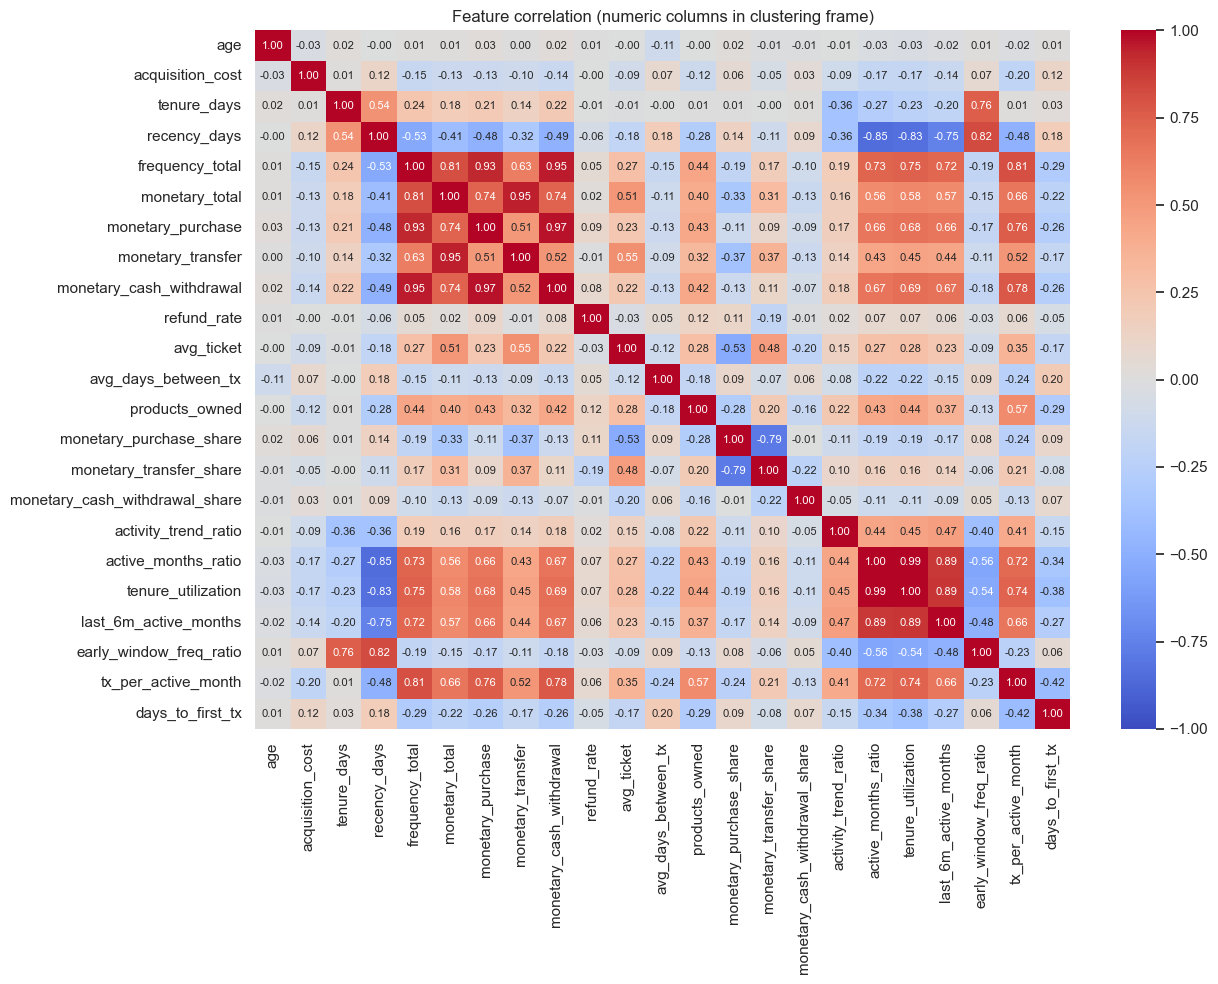

In [14]:
feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id"}
]

_corr = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation (numeric columns in clustering frame)")
plt.tight_layout()
plt.show()


#### Dropping highly correlated features

Why we dropped these columns?

**Raw BRL splits (`monetary_purchase`, `monetary_transfer`, `monetary_cash_withdrawal`)** — In the correlation heatmap they sit on the same axis as **`frequency_total`** (~0.93–0.96): higher activity mechanically raises counts and BRL in every type. We already keep **`frequency_total`**, **`avg_ticket`**, and **`monetary_*_share`** for *level* vs *mix*, so the raw splits double-weight “how big” the customer is in Euclidean space.

**`tenure_utilization` and `last_6m_active_months`** — Both are very highly correlated with **`active_months_ratio`** (~0.83–0.92): same idea (“how much of the window were they active / recent”). We keep **`active_months_ratio`** as the single primary “coverage” axis to avoid triple-counting engagement.


Dropped 5 columns: ['monetary_purchase', 'monetary_cash_withdrawal', 'monetary_transfer', 'tenure_utilization', 'last_6m_active_months']
Clustering feature count after prune: 18


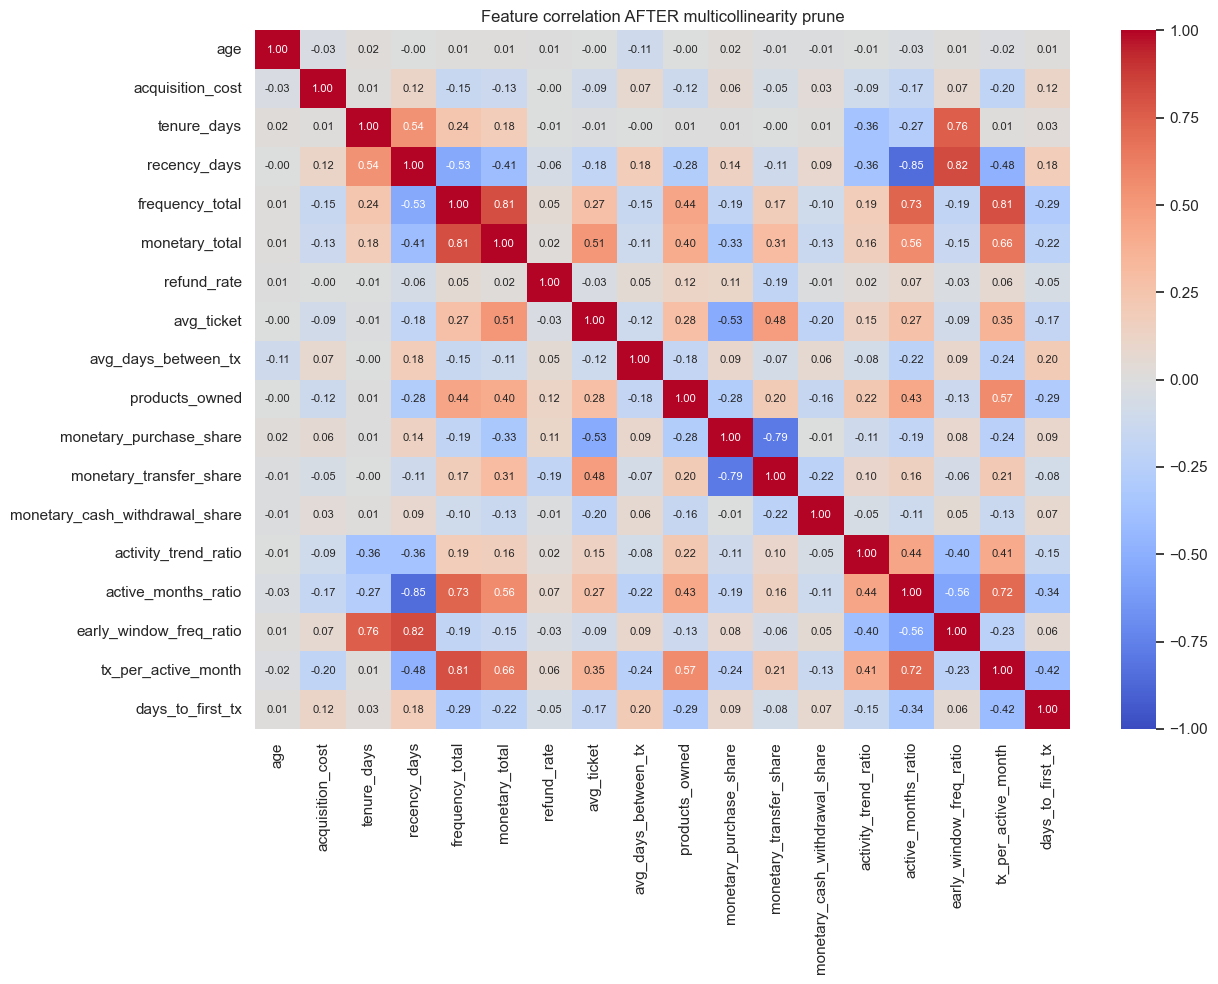

In [15]:
# Multicollinearity prune 
_MULTICOLLINEARITY_DROP = [
    "monetary_purchase",    # near-perfect proxy for monetary_total when purchases dominate
    "monetary_cash_withdrawal",
    "monetary_transfer",  # same pattern; mix signal is captured by *_share columns
    "tenure_utilization",   # alias of active_months_ratio (both = active_months / span); VIF > 10
    "last_6m_active_months",  # subsumed by active_months_ratio and activity_trend_ratio
]
_present = [c for c in _MULTICOLLINEARITY_DROP if c in df_clustering.columns]
if _present:
    df_clustering = df_clustering.drop(columns=_present)
    print(f"Dropped {len(_present)} columns: {_present}")
else:
    print("No columns from the prune list are present (already dropped or different schema).")

feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id"}
]
print(f"Clustering feature count after prune: {len(feature_cols)}")

_corr_pruned = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr_pruned,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation AFTER multicollinearity prune")
plt.tight_layout()
plt.show()


### 7. Raw distributions (before `log1p` / `sqrt`)

Skew-heavy axes (recency, frequency, ticket, …) are **not** Gaussian yet — that is expected. The preprocessing pipeline applies **`log1p`** to those columns before scaling so k-means distances are not dominated by a thin tail of extreme users.

[↑ Back to summary](#summary)

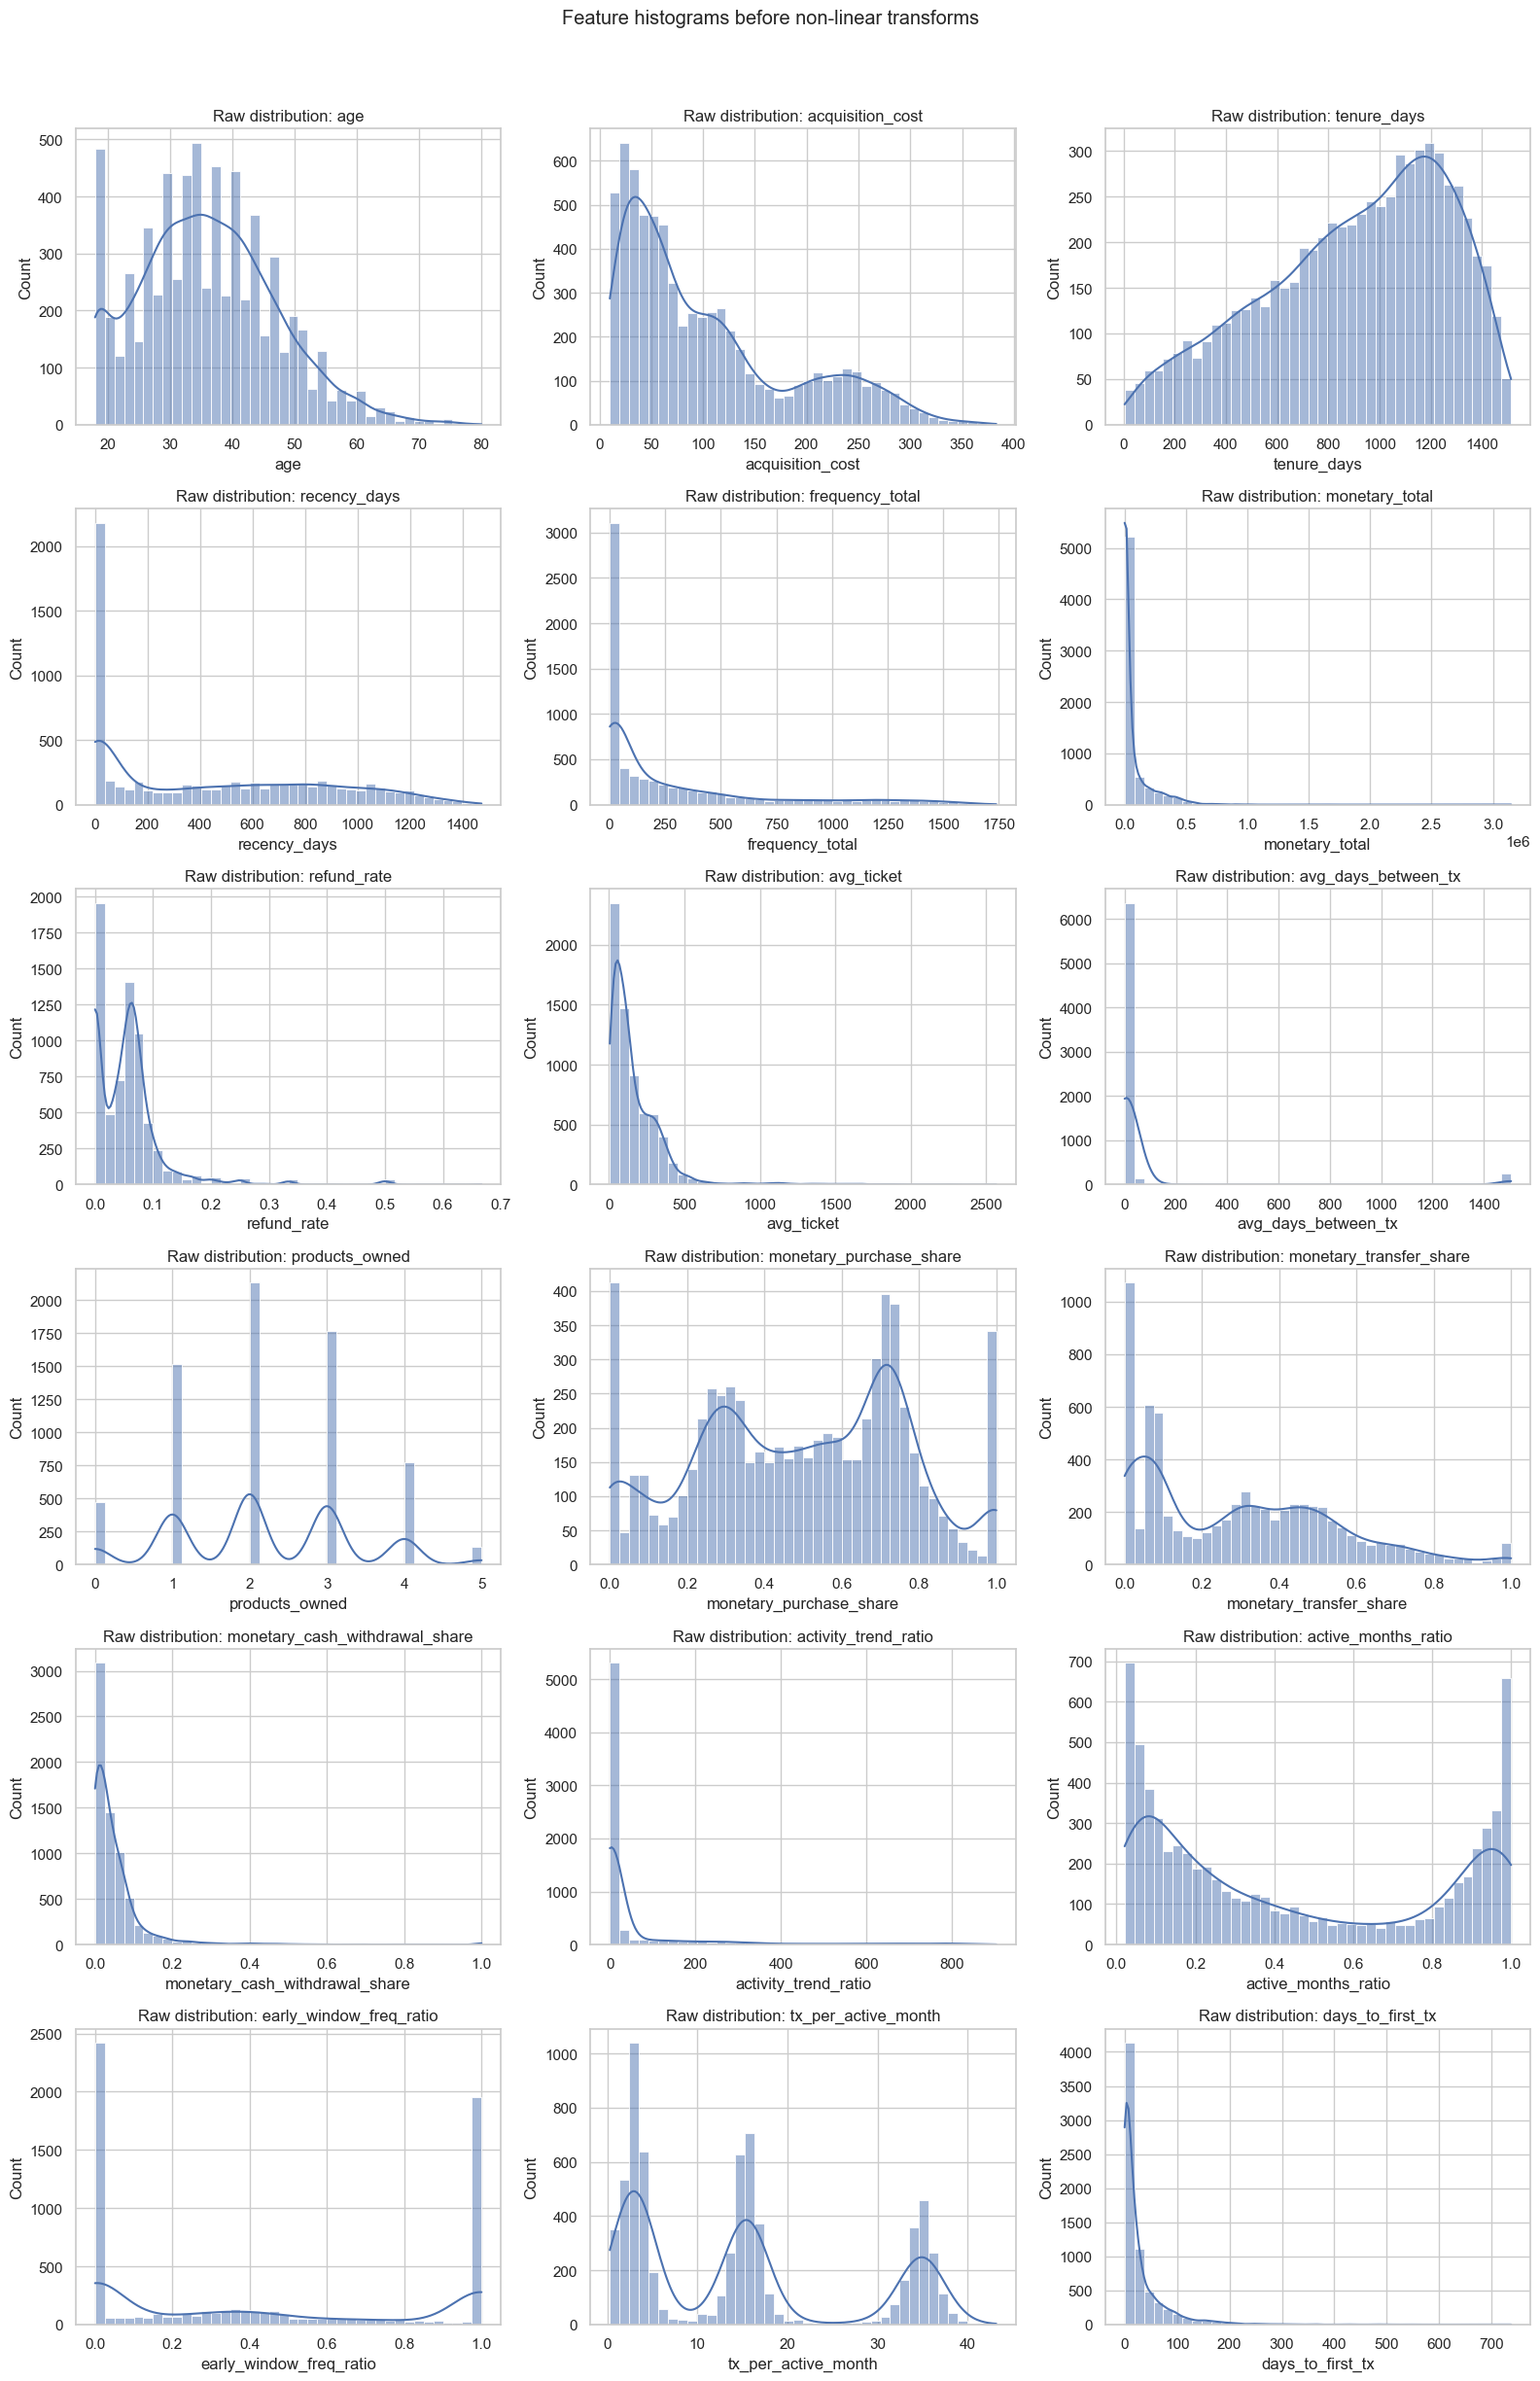

In [16]:
plot_cols = [c for c in feature_cols if c != "customer_id"]
if plot_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df_clustering[col].dropna(), bins=40, kde=True, ax=axes[i])
        axes[i].set_title(f"Raw distribution: {col}")

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature histograms before non-linear transforms", y=1.02)
    plt.tight_layout()
    plt.show()


### 8. Preprocessing fit (`ColumnTransformer` + `StandardScaler`)

`build_preprocessing_pipeline(feature_cols)` applies **`log1p`** to right-skewed magnitudes, **`sqrt`** to bounded rate features, passes through remaining columns unchanged, then **`StandardScaler`** on **all** transformed features — required so k-means Euclidean distance is not axis-dominated by BRL scale or mixed units.

[↑ Back to summary](#summary)

**Why these transforms?**

| Column | Transform | Rationale |
|--------|-----------|-----------|
| `recency_days` | `log1p` | Right-skewed: most customers transacted recently, a few extreme laggards |
| `frequency_total` | `log1p` | Pareto-style: few high-frequency customers dominate the raw scale |
| `avg_ticket` | `log1p` | BRL amounts vary by 2–3 orders of magnitude between segments |
| `avg_days_between_tx` | `log1p` | Same shape as recency — dominated by dormant customers |
| `acquisition_cost` | `log1p` | Multi-modal right tail (paid_ads vs organic differ by 10×) |
| `activity_trend_ratio` | `log1p` | Right-skewed ratio — growing customers can have ratios >> 1 |
| `tx_per_active_month` | `log1p` | Right-skewed intensity when active (high-value tail) |
| `days_to_first_tx` | `log1p` | Activation-speed lag is right-skewed (many quick activators, few very slow) |
| `refund_rate` | `sqrt` | Bounded [0, 1] with a spike at 0; lighter skew than log1p requires |
| `products_owned` | passthrough | Integer count, low variance, already on a natural scale |
| `age`, `tenure_days` | passthrough | Approximately normal; StandardScaler handles the scale difference |
| `active_months_ratio` | passthrough | Already bounded [0, 1] — no transform needed |
| `early_window_freq_ratio` | passthrough | Bounded [0, 1] behavior-share feature; keep linear interpretation |
| `monetary_*_share` | passthrough | Compositional shares [0, 1] — no transform needed |


`LOG1P_COLS` and `SQRT_COLS` are defined in `rfm_features.py` and drive the `ColumnTransformer` step inside `build_preprocessing_pipeline`. The pipeline is deterministic given the same feature list.


In [17]:
X_pre = df_clustering[feature_cols].copy()

# 1) Catch non-finite raw values (inf/-inf) before sklearn validation.
num_cols = X_pre.select_dtypes(include=[np.number]).columns.tolist()
inf_counts = (
    X_pre[num_cols].replace([np.inf, -np.inf], np.nan).isna().sum()
    - X_pre[num_cols].isna().sum()
)
inf_counts = inf_counts[inf_counts > 0]
if not inf_counts.empty:
    print("Columns with +/-inf detected:")
    display(inf_counts.sort_values(ascending=False).to_frame("n_inf"))

# 2) Sanitize values incompatible with log1p (<= -1) and infinities.
log_cols = [c for c in rfm.LOG1P_COLS if c in feature_cols]
bad_log_counts = {}
for c in log_cols:
    bad_mask = X_pre[c] <= -1
    n_bad = int(bad_mask.sum())
    if n_bad > 0:
        bad_log_counts[c] = n_bad
        X_pre.loc[bad_mask, c] = np.nan

if bad_log_counts:
    print("Invalid values for log1p (<= -1) converted to NaN:")
    display(pd.Series(bad_log_counts, name="n_bad_log_inputs").sort_values(ascending=False).to_frame())

X_pre = X_pre.replace([np.inf, -np.inf], np.nan)

# 3) Fill any remaining NaNs with 0 for preprocessing stability.
nan_counts = X_pre.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
if not nan_counts.empty:
    print("Columns with NaN before fit_transform (filled with 0):")
    display(nan_counts.sort_values(ascending=False).to_frame("n_nan"))
    X_pre = X_pre.fillna(0)

preproc = build_preprocessing_pipeline(feature_cols)
X_scaled = preproc.fit_transform(X_pre)

print("X_scaled shape:", X_scaled.shape)

# FunctionTransformer may not expose get_feature_names_out in some sklearn versions.
sqrt_cols = [c for c in rfm.SQRT_COLS if c in feature_cols and c not in log_cols]
pass_cols = [c for c in feature_cols if c not in log_cols and c not in sqrt_cols]
out_cols = log_cols + sqrt_cols + pass_cols

scaled_preview = pd.DataFrame(X_scaled, columns=out_cols)
display(scaled_preview.describe().T[["mean", "std", "min", "max"]].head(30))
display(df_clustering.head())


X_scaled shape: (6806, 18)


,mean,std,min,max
recency_days,1.002235e-16,1.000073,-1.704664,1.032226
frequency_total,0.000000e+00,1.000073,-1.759725,1.636698
avg_ticket,5.345252e-16,1.000073,-2.800177,3.123670
avg_days_between_tx,1.336313e-16,1.000073,-1.264843,3.773203
acquisition_cost,-2.839665e-16,1.000073,-2.186183,1.911804
activity_trend_ratio,-1.336313e-16,1.000073,-0.923303,2.538964
tx_per_active_month,-6.681566e-17,1.000073,-2.208755,1.499046
days_to_first_tx,3.340783e-17,1.000073,-1.685372,2.886980
refund_rate,-6.681566e-17,1.000073,-1.375790,4.534434
age,-5.011174e-17,1.000073,-1.650826,4.008512


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,refund_rate,avg_ticket,avg_days_between_tx,products_owned,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share,activity_trend_ratio,active_months_ratio,early_window_freq_ratio,tx_per_active_month,days_to_first_tx
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,27.79,980.0,0.0,1088.0,331602.82,0.066094,304.782004,0.901352,3.0,0.305494,0.486882,0.029241,3.504132,1.000000,0.221507,33.794612,0.141667
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,222.02,881.0,0.0,973.0,231403.60,0.068900,237.824872,0.905566,4.0,0.410613,0.296175,0.035274,4.508475,0.933955,0.180884,35.996132,1.112500
2,a98bdb67-7583-46ec-9597-edbbad7e826e,32,39.81,1254.0,0.0,1358.0,187103.94,0.055633,137.779043,0.923862,2.0,0.721920,0.077906,0.063313,1.500000,0.970973,0.399853,33.950000,0.814583
3,27044599-8351-4735-accb-36881f9b0781,40,52.54,1028.0,1.0,1117.0,242700.11,0.063705,217.278523,0.920086,4.0,0.428807,0.281056,0.049730,2.730000,0.977160,0.267681,33.848485,0.647917
4,f05b6038-ad20-4708-8dcf-346473ab2942,33,199.99,865.0,3.0,912.0,273189.09,0.044025,299.549441,0.946846,3.0,0.309571,0.426173,0.023328,9.505747,0.950150,0.094298,33.777778,0.206250


In [18]:
# Tail-risk ablation for K-Means input
# Keep these columns in the dataset for interpretation, but exclude them from clustering distance.
_KMEANS_TAIL_DROP = {
    "monetary_total",
    "monetary_cash_withdrawal_share",
}

_removed_from_kmeans = [c for c in feature_cols if c in _KMEANS_TAIL_DROP]
feature_cols = [c for c in feature_cols if c not in _KMEANS_TAIL_DROP]

print(f"Removed from K-Means feature set: {_removed_from_kmeans}")
print(f"Feature count after tail-risk ablation: {len(feature_cols)}")

# Rebuild preprocessing objects/matrices so all downstream steps use the updated feature set.
X_pre = df_clustering[feature_cols].copy()
log_cols = [c for c in rfm.LOG1P_COLS if c in feature_cols]
for c in log_cols:
    X_pre.loc[X_pre[c] <= -1, c] = np.nan

X_pre = X_pre.replace([np.inf, -np.inf], np.nan).fillna(0)

preproc = build_preprocessing_pipeline(feature_cols)
X_scaled = preproc.fit_transform(X_pre)

sqrt_cols = [c for c in rfm.SQRT_COLS if c in feature_cols and c not in log_cols]
pass_cols = [c for c in feature_cols if c not in log_cols and c not in sqrt_cols]
out_cols = log_cols + sqrt_cols + pass_cols

scaled_preview = pd.DataFrame(X_scaled, columns=out_cols)
display(scaled_preview.describe().T[["mean", "std", "min", "max"]].head(30))

Removed from K-Means feature set: ['monetary_total', 'monetary_cash_withdrawal_share']
Feature count after tail-risk ablation: 16


,mean,std,min,max
recency_days,1.002235e-16,1.000073,-1.704664,1.032226
frequency_total,0.000000e+00,1.000073,-1.759725,1.636698
avg_ticket,5.345252e-16,1.000073,-2.800177,3.123670
avg_days_between_tx,1.336313e-16,1.000073,-1.264843,3.773203
acquisition_cost,-2.839665e-16,1.000073,-2.186183,1.911804
activity_trend_ratio,-1.336313e-16,1.000073,-0.923303,2.538964
tx_per_active_month,-6.681566e-17,1.000073,-2.208755,1.499046
days_to_first_tx,3.340783e-17,1.000073,-1.685372,2.886980
refund_rate,-6.681566e-17,1.000073,-1.375790,4.534434
age,-5.011174e-17,1.000073,-1.650826,4.008512


### Why these two features are excluded from K-Means

`monetary_total` and `monetary_cash_withdrawal_share` are removed from the clustering input because their post-scaling tails remain extreme (`max` much higher than other features), which can overweight Euclidean distances and pull centroids toward a small number of outlier customers.

This is a robustness choice: the columns are still kept in the dataset for business interpretation/profiling, but they are excluded from the distance space used to fit K-Means so cluster boundaries better represent the core population.

<a id="part-3"></a>

## Part 3 — K-means: choosing **k**, training and evaluating

**Goal:** Train and evaluate cluster structure for **`k = 2..7`** with K-Means and using internal clustering diagnostics: **inertia** (elbow intuition), **mean silhouette** (separation quality), **Davies-Bouldin** (compactness/separation; lower is better), and **Calinski-Harabasz** (between-vs-within dispersion; higher is better). We also inspect **silhouette diagrams** per **`k`**.

[↑ Back to summary](#summary)


### 9. Feature ablation & PCA experiment — finding the best input set


**Why ablation?** K-means Euclidean distance treats every scaled feature dimension equally. Adding features that carry no segment-separation signal (e.g. `age`, `acquisition_cost`) adds noise to distances and can shrink the silhouette score. We test four configurations to find the input set that maximises cluster separation:

| Config | Features | Notes |
|--------|----------|-------|
| `full` | All scaled features | Current default — includes demographics |
| `core` | RFM + trajectory only | Drops `acquisition_cost`, `age` |
| `pca_full` | PCA on `full` (≥ 80 % variance) | Removes noise dimensions via compression |
| `pca_core` | PCA on `core` (≥ 80 % variance) | Core set + PCA compression |

**Demographic features as noise:** `age` and `acquisition_cost` describe *who* a customer is and *how they were acquired*, but segments are defined by *behavioral patterns* (activity rate, spend trajectory, product usage). Demographics may correlate weakly with segments but add irrelevant axes that pull centroids toward high-spend or older-registration customers independent of their behavioral cluster.

**Selection rule:** the configuration with the highest mean silhouette score across k ∈ {2, 3, 4} is selected. Silhouette is scale-invariant and measures cohesion vs. separation, making it appropriate for comparing across feature sets with different dimensionalities. Ties (within 0.002) are broken by Davies-Bouldin (lower is better).


In [19]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

_NOISE_FEATURES = {"age", "acquisition_cost"}

def _eval_kmeans(X, k=3, n_init=20, seed=42):
    km = KMeans(n_clusters=k, random_state=seed, n_init=n_init)
    lbl = km.fit_predict(X)
    return {
        "silhouette": silhouette_score(X, lbl),
        "davies_bouldin": davies_bouldin_score(X, lbl),
        "calinski_harabasz": calinski_harabasz_score(X, lbl),
        "labels": lbl,
    }

def _pca_reduce(X, var_threshold=0.80):
    pca = PCA(random_state=42)
    pca.fit(X)
    cumvar = pca.explained_variance_ratio_.cumsum()
    n_comp = int((cumvar >= var_threshold).argmax()) + 1
    return PCA(n_components=n_comp, random_state=42).fit_transform(X), n_comp

# ── Build core feature set (drop demographic noise) ──────────────────────────
core_feature_cols = [c for c in feature_cols if c not in _NOISE_FEATURES]

preproc_core = build_preprocessing_pipeline(core_feature_cols)
X_core = preproc_core.fit_transform(df_clustering[core_feature_cols])

# ── PCA reductions ────────────────────────────────────────────────────────────
X_pca_full, n_pca_full = _pca_reduce(X_scaled)
X_pca_core, n_pca_core = _pca_reduce(X_core)

print(f"core_feature_cols ({len(core_feature_cols)}): {core_feature_cols}")
print(f"PCA(full): {X_scaled.shape[1]} → {n_pca_full} components")
print(f"PCA(core): {X_core.shape[1]} → {n_pca_core} components")

core_feature_cols (14): ['tenure_days', 'recency_days', 'frequency_total', 'refund_rate', 'avg_ticket', 'avg_days_between_tx', 'products_owned', 'monetary_purchase_share', 'monetary_transfer_share', 'activity_trend_ratio', 'active_months_ratio', 'early_window_freq_ratio', 'tx_per_active_month', 'days_to_first_tx']
PCA(full): 16 → 6 components
PCA(core): 14 → 5 components


With helper functions and feature matrices ready, we evaluate each configuration across k ∈ {2, 3, 4}. The loop records silhouette, Davies-Bouldin, and Calinski-Harabasz for each combination. **The global best (max silhouette across all k and configs) is selected as `best_config`** and used for all downstream k=2..7 evaluation and the final model fit.

In [20]:
# ── Evaluate across k ∈ {2, 3, 4} ─────────────────────────────────────────────
K_RANGE = [2, 3, 4]

def _nfeat_for_config(name: str) -> int:
    if name == "full":
        return X_scaled.shape[1]
    if name == "core":
        return X_core.shape[1]
    if name == "pca_full":
        return n_pca_full
    if name == "pca_core":
        return n_pca_core
    raise ValueError(name)

configs = {
    "full": X_scaled,
    "core": X_core,
    "pca_full": X_pca_full,
    "pca_core": X_pca_core,
}

rows_ab = []
for k in K_RANGE:
    for name, Xmat in configs.items():
        res = _eval_kmeans(Xmat, k=k)
        rows_ab.append({
            "k": k,
            "config": name,
            "n_features": _nfeat_for_config(name),
            "n_pca_note": n_pca_full if name == "pca_full" else (n_pca_core if name == "pca_core" else "—"),
            "silhouette": round(res["silhouette"], 4),
            "davies_bouldin": round(res["davies_bouldin"], 4),
            "calinski_harabasz": round(res["calinski_harabasz"], 1),
        })

df_ablation = pd.DataFrame(rows_ab)
print(f"=== Feature ablation & PCA experiment (k ∈ {K_RANGE}) ===")
display(df_ablation.sort_values(["k", "silhouette"], ascending=[True, False]))

# Best config per k (by silhouette)
for k in K_RANGE:
    sub = df_ablation[df_ablation["k"] == k]
    best_row = sub.loc[sub["silhouette"].idxmax()]
    print(
        f"Best @ k={k}: '{best_row['config']}'  "
        f"(silhouette={best_row['silhouette']:.4f})"
    )

# Global best (max silhouette across all k and configs)
best_row = df_ablation.loc[df_ablation["silhouette"].idxmax()]
best_config = str(best_row["config"])  # "full" | "core" | "pca_full" | "pca_core"
best_k_ablation = int(best_row["k"])
print(
    f"\nGlobal best: k={best_k_ablation}, config='{best_config}'  "
    f"(silhouette={best_row['silhouette']:.4f})"
)

=== Feature ablation & PCA experiment (k ∈ [2, 3, 4]) ===


,k,config,n_features,n_pca_note,silhouette,davies_bouldin,calinski_harabasz
3,2,pca_core,5,5,0.3266,1.2389,4078.9
2,2,pca_full,6,6,0.2955,1.3487,3491.8
1,2,core,14,—,0.2761,1.4292,3104.1
0,2,full,16,—,0.2446,1.5775,2590.4
7,3,pca_core,5,5,0.2748,1.3094,3323.7
6,3,pca_full,6,6,0.2315,1.4736,2714.7
5,3,core,14,—,0.2175,1.5485,2413.4
4,3,full,16,—,0.1819,1.7390,1958.7
11,4,pca_core,5,5,0.2740,1.3391,2925.5
10,4,pca_full,6,6,0.2274,1.5764,2320.8


Best @ k=2: 'pca_core'  (silhouette=0.3266)
Best @ k=3: 'pca_core'  (silhouette=0.2748)
Best @ k=4: 'pca_core'  (silhouette=0.2740)

Global best: k=2, config='pca_core'  (silhouette=0.3266)


### Model selection note: choosing `k=3` for operational segmentation

Although `k=2` has the highest silhouette (`0.3266`), we select **`k=3`** (`0.2748`) because it yields a more actionable structure for the transacting population: **high-value active**, **mid-value regular**, and **low-value dormant**.

This is an intentional business-statistical trade-off:
- `k=2` is more compact mathematically but tends to merge the middle and lower-value behaviors.
- `k=3` keeps distinct lifecycle/value patterns that are easier to profile and activate in CRM actions.
- Customers with no transactions are handled outside k-means via lifecycle rules (`inactive_no_tx` / `churned_pre_window`), so the clustering objective is to separate behavior among active/transacting customers.

Given this objective, `k=3` is adopted as the operational choice for `pca_core`.

In [21]:
best_config = 'pca_core'
best_k_ablation = 3
best_row = df_ablation.loc[
    (df_ablation["config"] == "pca_core") & (df_ablation["k"] == 3)
].iloc[0]

best_row

k                           3
config               pca_core
n_features                  5
n_pca_note                  5
silhouette             0.2748
davies_bouldin         1.3094
calinski_harabasz      3323.7
Name: 7, dtype: object

### 10. Applying the best config from the ablation experiment

In [22]:
k_selected = 3  # ground-truth count of segments

# Apply best config from ablation experiment
# "Best" = highest silhouette score across all k and configs in df_ablation.
# We re-run the k=2..7 scan with this config so elbow/silhouette charts
# reflect the chosen feature space — not the full-feature default.
if "best_row" not in globals() and "df_ablation" in globals():
    best_row = df_ablation.loc[df_ablation["silhouette"].idxmax()]
if "best_row" not in globals():
    raise RuntimeError("Run the feature ablation cell above first (defines df_ablation + best_row).")
if "best_config" not in globals():
    best_config = str(best_row["config"])

BEST_FEATURE_CONFIG = best_config
_best_sil = float(best_row["silhouette"])

if BEST_FEATURE_CONFIG == "pca_full":
    X_for_km = X_pca_full
    print(f"Using PCA (full features → {n_pca_full} components, silhouette={_best_sil:.4f})")
elif BEST_FEATURE_CONFIG == "pca_core":
    X_for_km = X_pca_core
    print(f"Using PCA (core features → {n_pca_core} components, silhouette={_best_sil:.4f})")
elif BEST_FEATURE_CONFIG == "core":
    X_for_km = X_core
    print(f"Using core features ({X_core.shape[1]} features, silhouette={_best_sil:.4f})")
else:
    X_for_km = X_scaled   # default: full features
    print(f"Using full scaled features ({X_scaled.shape[1]} features, silhouette={_best_sil:.4f})")

# Also re-run the k=2..7 scan with the best config so the elbow/silhouette charts
# reflect the chosen feature space
k_values_scan = list(range(2, 8))
rows_scan = []
labels_by_k_best = {}
for k in k_values_scan:
    km_s = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl_s = km_s.fit_predict(X_for_km)
    labels_by_k_best[k] = lbl_s
    rows_scan.append({
        "k": k,
        "inertia": float(km_s.inertia_),
        "silhouette": float(silhouette_score(X_for_km, lbl_s)),
        "davies_bouldin": float(davies_bouldin_score(X_for_km, lbl_s)),
        "calinski_harabasz": float(calinski_harabasz_score(X_for_km, lbl_s)),
    })

k_eval_best = pd.DataFrame(rows_scan)

# Canonical evaluation objects for downstream cells.
k_eval = k_eval_best.copy()
labels_by_k = labels_by_k_best

k_eval["inertia_prev"] = k_eval["inertia"].shift(1)
k_eval["inertia_drop_pct"] = (
    (k_eval["inertia_prev"] - k_eval["inertia"]) / k_eval["inertia_prev"]
)

k_silhouette_max = int(k_eval.loc[k_eval["silhouette"].idxmax(), "k"])
k_dbi_min = int(k_eval.loc[k_eval["davies_bouldin"].idxmin(), "k"])
k_ch_max = int(k_eval.loc[k_eval["calinski_harabasz"].idxmax(), "k"])


display(
    k_eval[["k", "inertia", "inertia_drop_pct", "silhouette", "davies_bouldin", "calinski_harabasz"]]
    .sort_values("k")
    .reset_index(drop=True)
)

# Import needed metrics for silhouette diagrams in later cells
from sklearn.metrics import silhouette_samples


Using PCA (core features → 5 components, silhouette=0.2748)


,k,inertia,inertia_drop_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,49743.903645,NaN,0.326629,1.238873,4078.923361
1,3,40242.401129,0.191008,0.274785,1.309437,3323.731043
2,4,34740.027380,0.136731,0.273974,1.339111,2925.520406
3,5,30188.829051,0.131007,0.266560,1.363583,2780.879272
4,6,26963.113235,0.106851,0.278104,1.265701,2653.187882
5,7,24568.945324,0.088794,0.277706,1.200629,2536.517018


### 11. Elbow and mean silhouette (line charts)

Use these plots together: the **elbow** is often ambiguous on marketing/behavioral data; **mean silhouette** penalises overlap but can favour **too few** clusters. The next subsection shows **full silhouette blades** per **`k`** (per-sample coefficients).


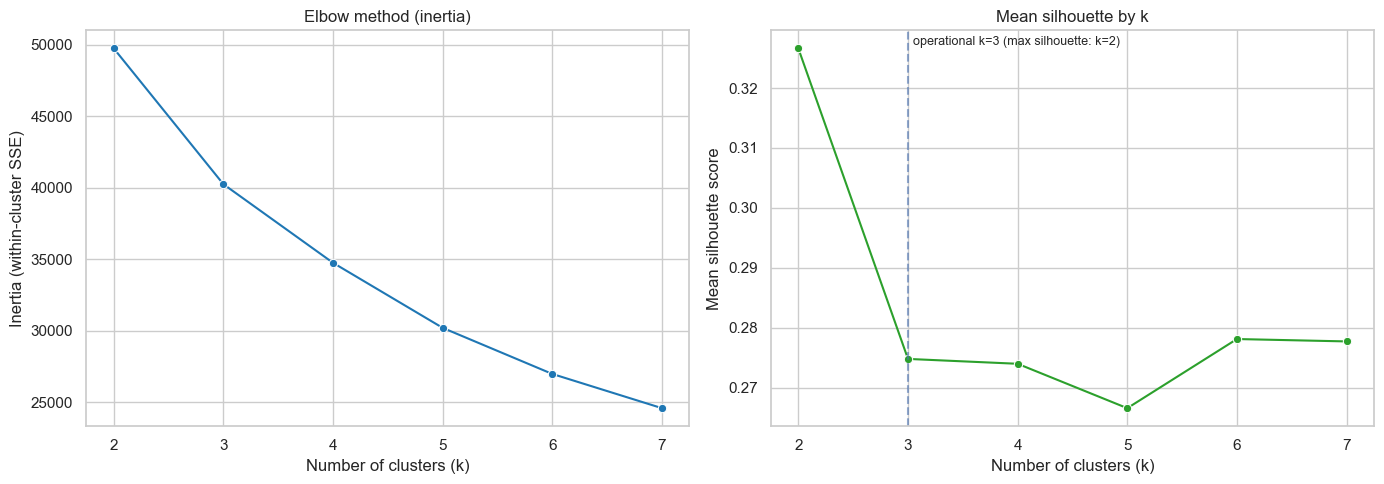

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

sns.lineplot(
    data=k_eval,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
    color="#2ca02c",
)
axes[1].set_title("Mean silhouette by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Mean silhouette score")
axes[1].axvline(k_selected, linestyle="--", alpha=0.6)
axes[1].text(
    k_selected + 0.05,
    k_eval["silhouette"].max(),
    f"operational k={k_selected} (max silhouette: k={k_silhouette_max})",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()


### 12. Silhouette diagrams per k (full coefficient profiles)

Each panel sorts samples by cluster blocks. The vertical dashed line is the **mean** silhouette for that **`k`**. Use this to spot **over-splitting** (many small negative slices) vs **stable** separation.


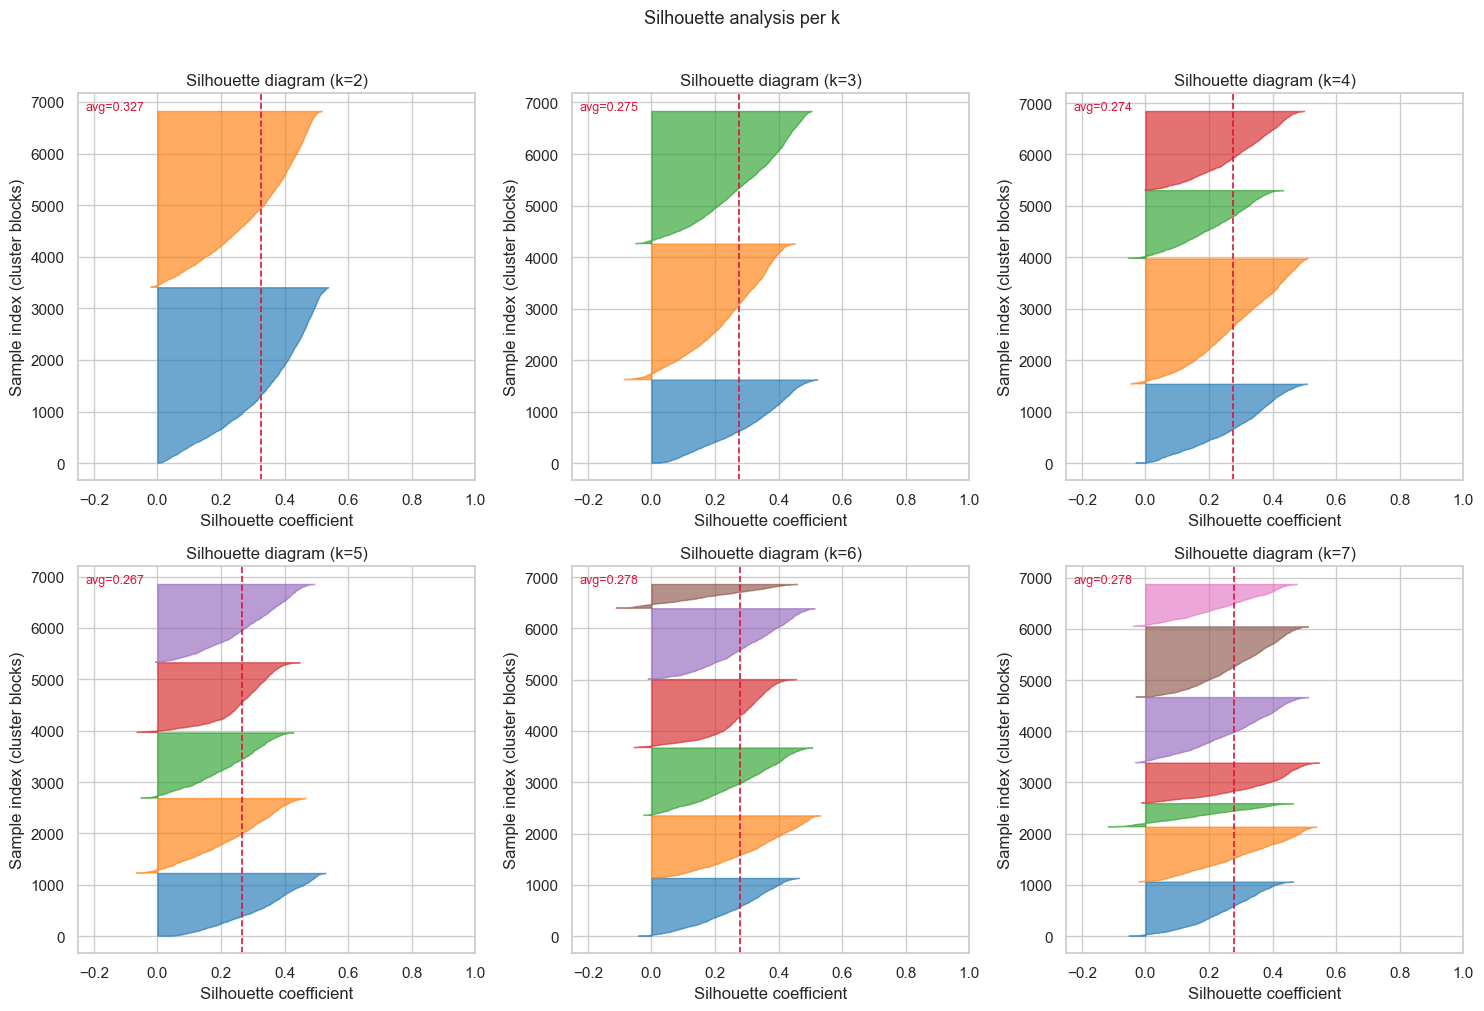

In [24]:
fig_sil, axes_sil = plt.subplots(2, 3, figsize=(15, 10))
axes_sil = axes_sil.flatten()

for ax_idx, k in enumerate(k_values_scan):
    ax = axes_sil[ax_idx]
    cluster_labels = labels_by_k[k]
    sil_avg = float(k_eval.loc[k_eval["k"] == k, "silhouette"].iloc[0])
    sample_silhouette_values = silhouette_samples(X_for_km, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(i % 10)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.65,
        )
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_title(f"Silhouette diagram (k={k})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Sample index (cluster blocks)")
    ax.set_xlim(-0.25, 1.0)
    ax.text(
        0.02,
        0.98,
        f"avg={sil_avg:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        color="crimson",
    )

plt.suptitle("Silhouette analysis per k", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


### 13 . Final k and interpretation — metrics, elbow, mean silhouette, and silhouette diagrams

#### Choosing the operational `k`

The diagnostics support **`k=3`** as the operational choice.

- **Mean silhouette (`higher is better`):** `k=3` scores `0.2748` vs `0.3266` at `k=2` and `0.2740` at `k=4`. Rule of thumb: `~0.25-0.50` indicates usable structure (not perfectly separated), so `k=3` is acceptable and effectively tied with `k=4`.
- **Davies-Bouldin (`lower is better`):** `k=3` is `1.3094` (vs `1.2389` at `k=2` and `1.3391` at `k=4`). Rule of thumb: values around `1-1.5` usually indicate moderate but workable separation in behavioral data; `k=3` sits in that acceptable range.
- **Calinski-Harabasz (`higher is better`):** `k=3` is `3323.7` (below `k=2`, above `k>=4`). Rule of thumb: there is no universal cutoff; it is comparative. After excluding `k=2` as too coarse, `k=3` provides the strongest compactness/separation trade-off among practical options.
- **Inertia/elbow:** inertia drops strongly from `k=2 -> 3` (`-19.1%`) and then shows diminishing gains as `k` increases, supporting a parsimonious solution.
- **Business interpretability:** `k=3` maps cleanly to the transacting archetypes (**high-value active**, **mid-value regular**, **low-value dormant**), which improves action design and communication.

**Decision:** keep **`k=3`** to balance statistical quality, parsimony, and operational actionability.

### 14. Fit k-means at operational k

We fit **one** production-style model at **`k = k_selected = 3`**, assign **`cluster_km`**, and profile clusters below (PCA is **visualisation only** — not used to fit k-means).


In [25]:
k_fit = int(k_selected)   # 3
km_fit = KMeans(n_clusters=k_fit, random_state=42, n_init=20)
labels_km = km_fit.fit_predict(X_for_km)

df_clustering = df_clustering.copy()
df_clustering["cluster_km"] = labels_km

cluster_sizes = (
    df_clustering["cluster_km"].value_counts().sort_index().rename("n_customers")
)
print(f"Cluster sizes (k={k_fit}) [{BEST_FEATURE_CONFIG} features]:")
print(cluster_sizes.to_string())

final_sil = silhouette_score(X_for_km, labels_km)
print(f"\nFinal k=3 silhouette ({BEST_FEATURE_CONFIG}): {final_sil:.4f}")


Cluster sizes (k=3) [pca_core features]:
cluster_km
0    1613
1    2629
2    2564

Final k=3 silhouette (pca_core): 0.2748


### 15. Visualising clusters (PCA projection + feature profiles)

Two views are used to interpret the selected solution:

- **2D scatter from `pca_core`** — K-Means is fitted on the selected **5-component** `pca_core` representation, and the visualization shows the cluster separation on this same PCA-based space.
- **Boxplots** on interpretable **raw** columns in `df_clustering` — this remains the primary business readout to label and explain each cluster behavior.


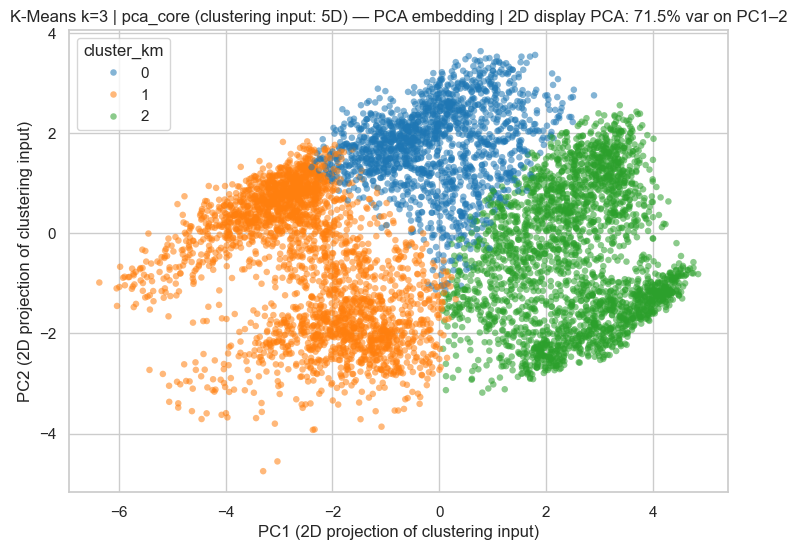

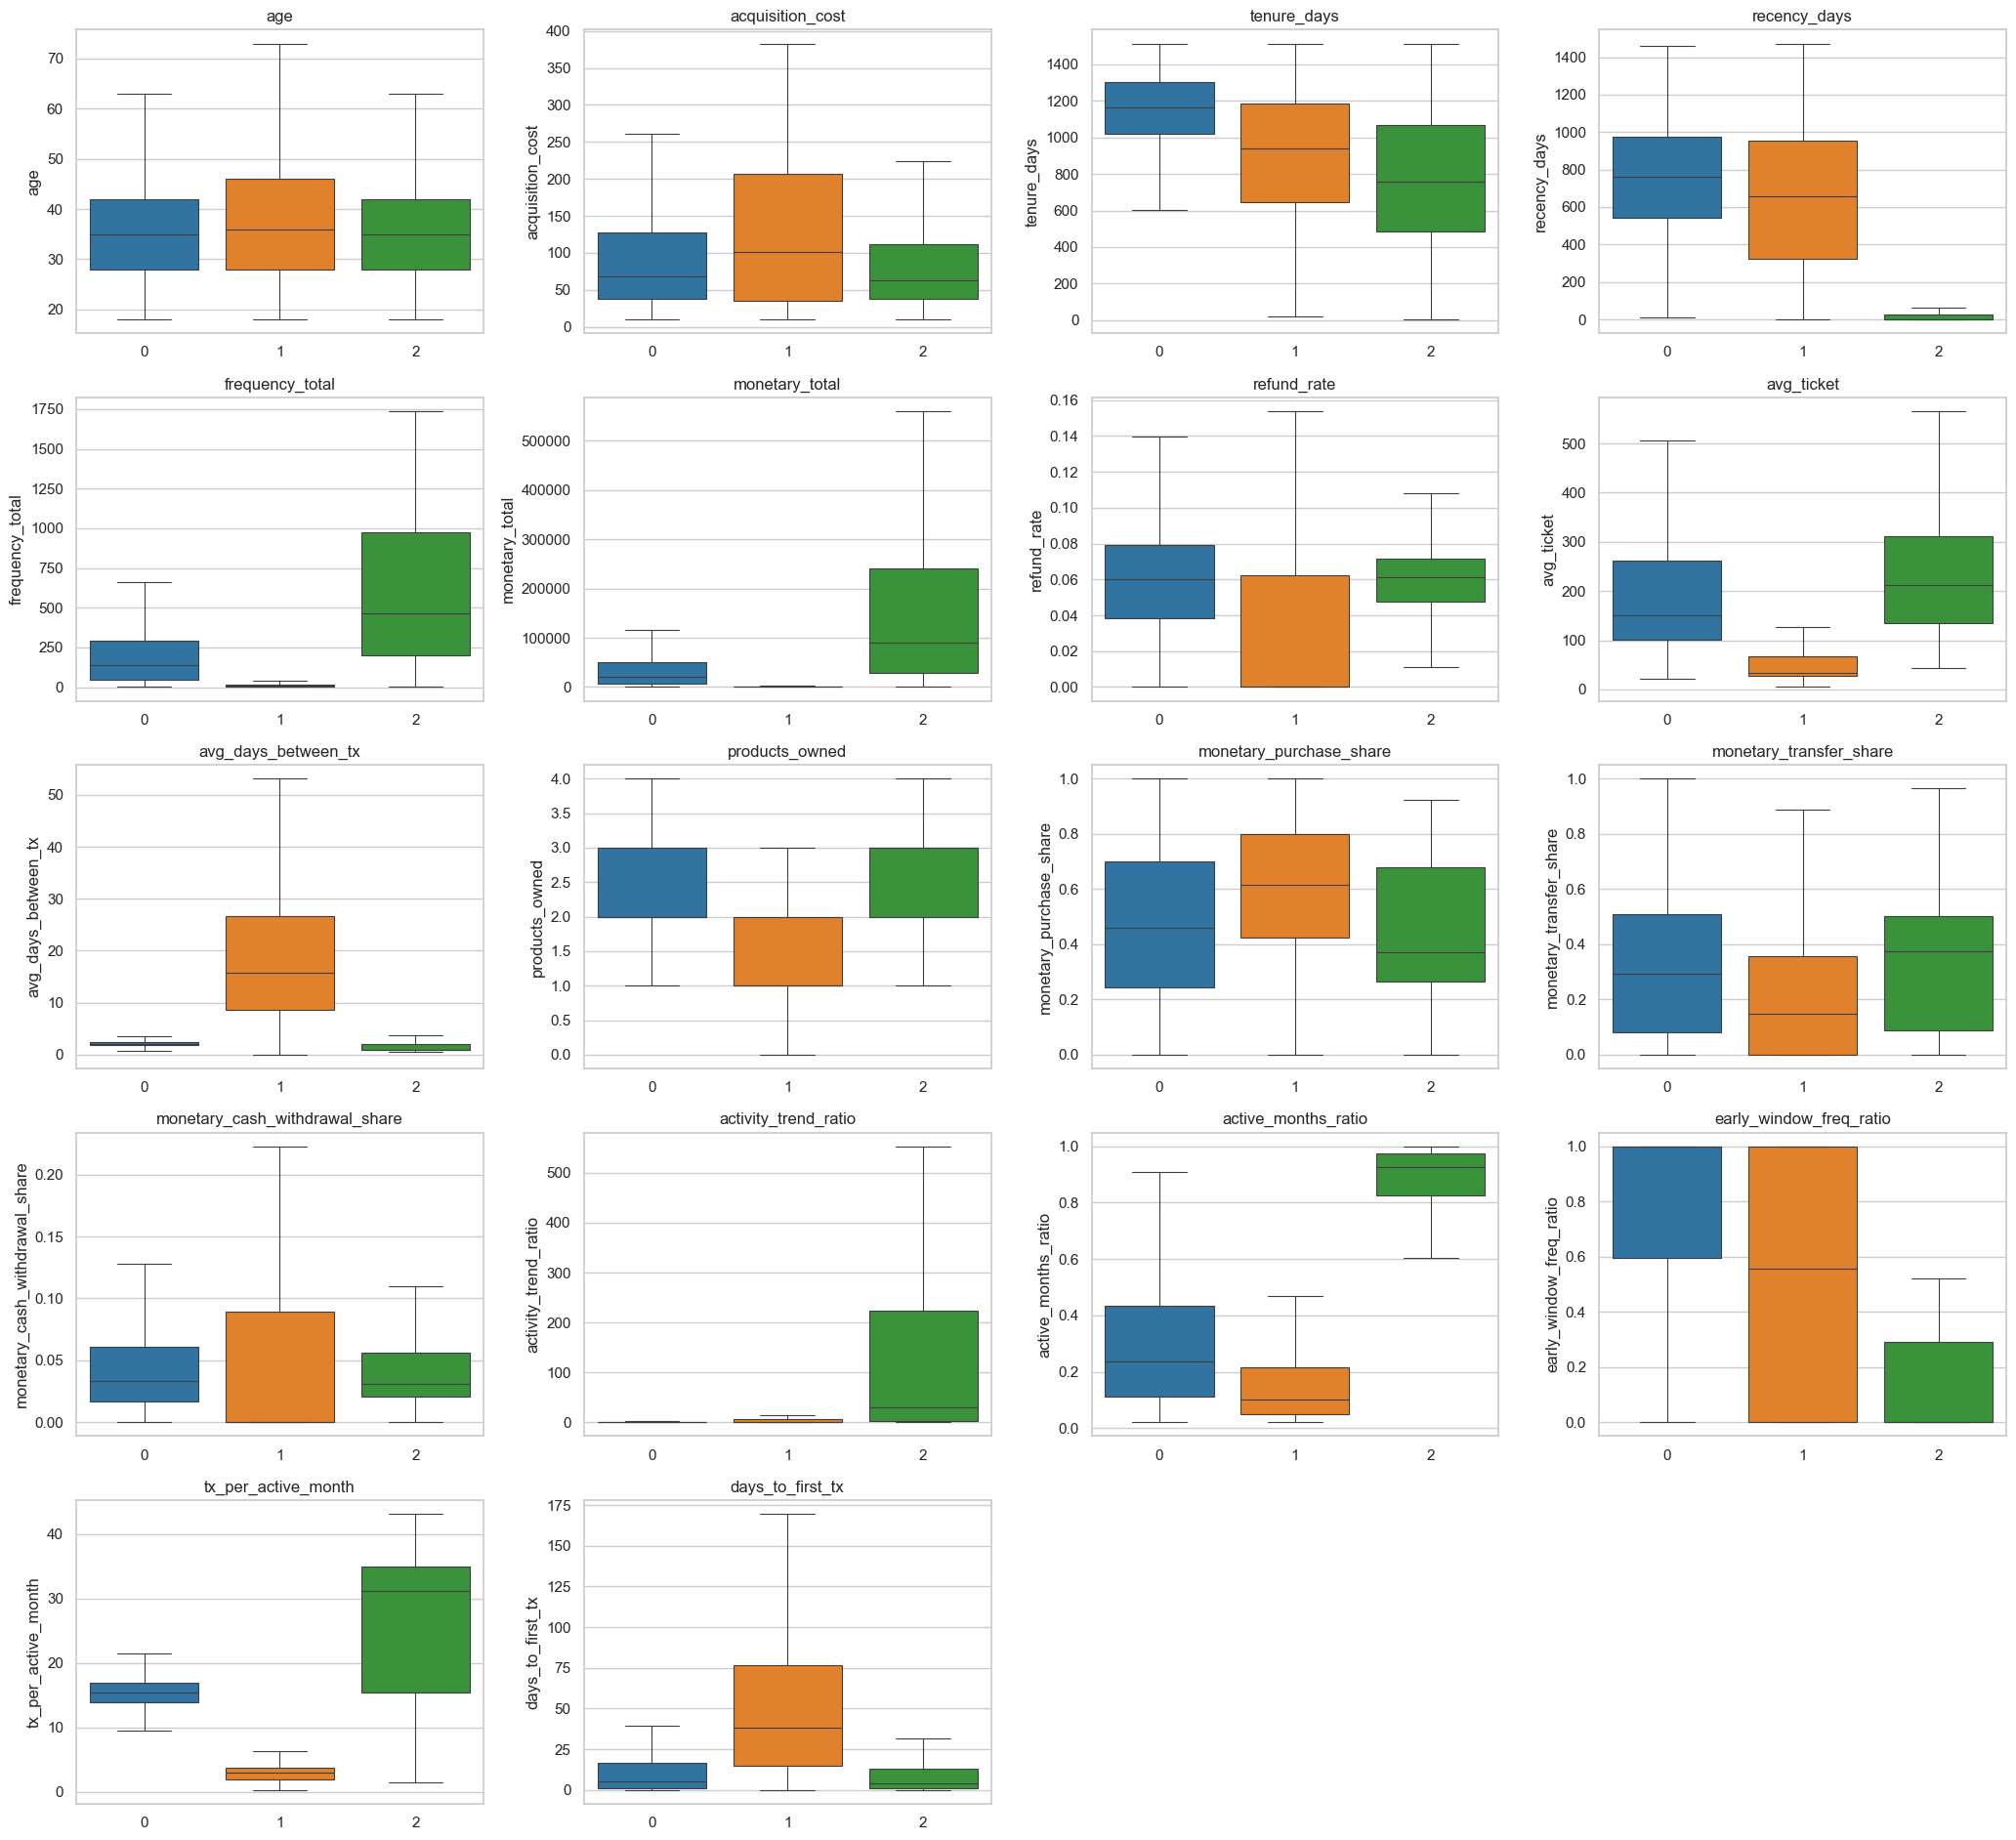

In [26]:
from sklearn.decomposition import PCA

plot_df = df_clustering.copy()

pca2d = PCA(n_components=2, random_state=42)
X_pca = pca2d.fit_transform(X_for_km)
plot_df["pc1"] = X_pca[:, 0]
plot_df["pc2"] = X_pca[:, 1]

fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))

# PCA scatter — cluster_km
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="cluster_km",
    palette="tab10",
    alpha=0.55,
    s=22,
    linewidth=0,
    ax=ax,
)
_d_in = X_for_km.shape[1]
_viz_pct = pca2d.explained_variance_ratio_.sum() * 100
ax.set_title(
    f"K-Means k={k_fit} | {BEST_FEATURE_CONFIG} (clustering input: {_d_in}D)"
    + (" — PCA embedding" if str(BEST_FEATURE_CONFIG).startswith("pca") else "")
    + f" | 2D display PCA: {_viz_pct:.1f}% var on PC1–2"
)
ax.set_xlabel("PC1 (2D projection of clustering input)")
ax.set_ylabel("PC2 (2D projection of clustering input)")
ax.legend(title="cluster_km")

# Feature profile — boxplot for all numeric feature columns in df_clustering
exclude_cols = {"customer_id", "cluster_km", "cluster_gmm"}
feature_view = [
    c
    for c in df_clustering.select_dtypes(include="number").columns
    if c not in exclude_cols and not str(c).startswith("cluster_")
]

n_f = len(feature_view)
n_cols_f = 4
n_rows_f = max(1, int(np.ceil(n_f / n_cols_f)))

fig2, axes2 = plt.subplots(n_rows_f, n_cols_f, figsize=(5.2 * n_cols_f, 3.8 * n_rows_f))
axes2 = axes2.flatten()
for ax_i, col in enumerate(feature_view):
    ax = axes2[ax_i]
    sns.boxplot(
        data=df_clustering,
        x="cluster_km",
        y=col,
        hue="cluster_km",
        palette="tab10",
        legend=False,
        showfliers=False,
        ax=ax,
        linewidth=0.8,
    )
    ax.set_title(col)
    ax.set_xlabel("")
for ax_i in range(len(feature_view), len(axes2)):
    axes2[ax_i].set_visible(False)

plt.tight_layout()
plt.show()


#### Product penetration and activity gap by cluster

To better understand the business potential inside each of the **k=3 clusters**, we profile them on two product dimensions:

1. **Penetration** — what share of customers in the cluster **own** each product (point-in-time snapshot at `as_of_date`).
2. **Activity (last 6 months)** — what share made **at least one transaction** in each product within the 6-month period before `as_of_date`.
3. **Gap** — `penetration - activity`: customers who own a product but haven't used it recently. This is the primary activation opportunity metric.

**Why 6 months?** The 6-month horizon aligns with the **M6 cohort window** used in Notebook 2 (cohort analysis), where M6 first-month-active rate was the primary channel quality signal. A customer who owns a product but made no transaction in 6 months is effectively inactive in that product — below the threshold we'd consider "regularly engaged." Shorter windows (e.g. 3 months) would over-penalise seasonal products; longer windows (12 months) would miss customers in the early stages of disengagement.


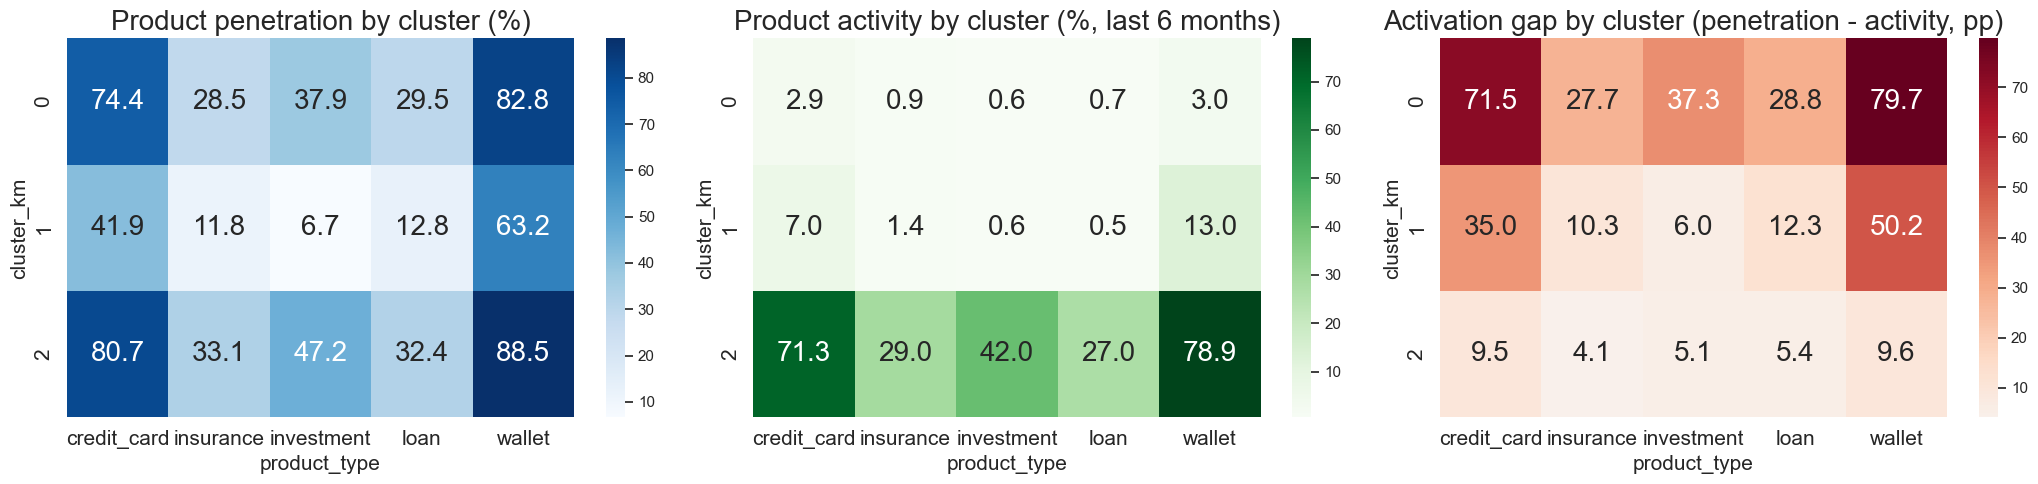

In [27]:
# K-means clusters (k=3) business read: product penetration + product activity gap

# 0) Resolve cluster assignment
if "df_clustering" not in globals():
    raise ValueError("df_clustering not found. Run Part 4 (k-means clustering) first.")

if "cluster_km" not in df_clustering.columns:
    if "labels_km" in globals() and len(labels_km) == len(df_clustering):
        df_clustering = df_clustering.copy()
        df_clustering["cluster_km"] = labels_km
    else:
        raise ValueError("cluster_km not found in df_clustering and labels_km is unavailable.")

cluster_map = df_clustering[["customer_id", "cluster_km"]].copy()

# 1) Product penetration (ownership) by cluster
cp_active = df_customer_products.copy()
if "is_active" in cp_active.columns:
    cp_active = cp_active[cp_active["is_active"] == True].copy()

cp_prod = cp_active.merge(df_products[["product_id", "product_type"]], on="product_id", how="left")
own_pairs = cp_prod[["customer_id", "product_type"]].dropna().drop_duplicates()

# Build full customer x product grid to keep the denominator correct.
# Without this grid, rates are inflated because only observed pairs are averaged.
all_product_types = sorted(df_products["product_type"].dropna().unique().tolist())
customer_product_base = (
    cluster_map.assign(_k=1)
    .merge(pd.DataFrame({"product_type": all_product_types, "_k": 1}), on="_k", how="left")
    .drop(columns="_k")
)

owner_flags = customer_product_base.merge(
    own_pairs.assign(owner_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
owner_flags["owner_flag"] = owner_flags["owner_flag"].fillna(0)

penetration = (
    owner_flags.groupby(["cluster_km", "product_type"], as_index=False)["owner_flag"]
    .mean()
    .rename(columns={"owner_flag": "penetration_rate"})
)
penetration["penetration_rate"] *= 100

# 2) Product activity by cluster (has >=1 tx in product_type over last 6 months)
# Anchor on as_of_date; fallback to max df_tx timestamp if as_of_date is unavailable.
_as_of = pd.Timestamp(as_of_date) if "as_of_date" in globals() else pd.Timestamp(df_tx["transaction_datetime"].max())
if _as_of.tzinfo is not None:
    _as_of = _as_of.tz_convert(None)  # tz_localize raises TypeError on tz-aware Timestamps

window_start_6m = _as_of - pd.DateOffset(months=6)

tx_recent_6m = df_tx.copy()
tx_recent_6m["transaction_datetime"] = pd.to_datetime(tx_recent_6m["transaction_datetime"], errors="coerce")
if isinstance(tx_recent_6m["transaction_datetime"].dtype, pd.DatetimeTZDtype):
    tx_recent_6m["transaction_datetime"] = tx_recent_6m["transaction_datetime"].dt.tz_convert("UTC").dt.tz_localize(None)

tx_recent_6m = tx_recent_6m[
    tx_recent_6m["transaction_datetime"].between(window_start_6m, _as_of, inclusive="both")
].copy()

activity_pairs = tx_recent_6m[["customer_id", "product_type"]].dropna().drop_duplicates()
activity_flags = customer_product_base.merge(
    activity_pairs.assign(active_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
activity_flags["active_flag"] = activity_flags["active_flag"].fillna(0)

activity = (
    activity_flags.groupby(["cluster_km", "product_type"], as_index=False)["active_flag"]
    .mean()
    .rename(columns={"active_flag": "activity_rate"})
)
activity["activity_rate"] *= 100

# 3) Gap table (penetration - activity)
prod_gap = penetration.merge(activity, on=["cluster_km", "product_type"], how="outer").fillna(0.0)
prod_gap["gap_pen_minus_act"] = prod_gap["penetration_rate"] - prod_gap["activity_rate"]

gap_pivot = prod_gap.pivot(index="cluster_km", columns="product_type", values="gap_pen_minus_act")
pen_pivot = prod_gap.pivot(index="cluster_km", columns="product_type", values="penetration_rate")
act_pivot = prod_gap.pivot(index="cluster_km", columns="product_type", values="activity_rate")

#print("Product penetration by cluster (% customers owning active product):")
#display(pen_pivot.round(2))
#print("Product activity by cluster (% customers with >=1 tx in product, last 6 months):")
#display(act_pivot.round(2))
#print("Gap = penetration - activity (pp): positive means under-activation among owners")
#display(gap_pivot.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.heatmap(
    pen_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[0],
    annot_kws={"size": 20},
)
axes[0].set_title("Product penetration by cluster (%)", fontsize=20)
axes[0].set_xlabel("product_type", fontsize=15)
axes[0].set_ylabel("cluster_km", fontsize=15)
axes[0].tick_params(axis="both", labelsize=15)

sns.heatmap(
    act_pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    ax=axes[1],
    annot_kws={"size": 20},
)
axes[1].set_title("Product activity by cluster (%, last 6 months)", fontsize=20)
axes[1].set_xlabel("product_type", fontsize=15)
axes[1].set_ylabel("cluster_km", fontsize=15)
axes[1].tick_params(axis="both", labelsize=15)

sns.heatmap(
    gap_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0.0,
    ax=axes[2],
    annot_kws={"size": 20},
)
axes[2].set_title("Activation gap by cluster (penetration - activity, pp)", fontsize=20)
axes[2].set_xlabel("product_type", fontsize=15)
axes[2].set_ylabel("cluster_km", fontsize=15)
axes[2].tick_params(axis="both", labelsize=15)

plt.tight_layout()
plt.show()


<a id="part-4"></a>

## Part 4 - Clusters profiles, business questions and answers & Customer analysis mart

[↑ Back to summary](#summary)


### 16. Clusters Profile and deep-dive plan:

With `k=3`, the solution separates three **different kinds of customer story**, not just “low / mid / high” on a single axis.

- **Cluster `2` — active core (high-value today)**  
  Lowest `recency_days`, highest `frequency_total` and `monetary_total`, strong `avg_ticket`, very high `active_months_ratio` and `tx_per_active_month`, and healthier trajectory signals (`activity_trend_ratio` skews positive where relevant). `early_window_freq_ratio` tends **low**: activity is not only front-loaded in the global window — it looks **sustained or growing** versus the first half. Product heatmaps show **high penetration and high last-6m activity** with **small activation gaps** — these are engaged owners, not shelf products.

- **Cluster `0` — lapsed legacy engaged (historical depth, current dormancy)**  
  **Highest `tenure_days`** and often **high `early_window_freq_ratio`**: in the global analysis window, much of their transaction history sits in the **first half** (calendar split), which reads as “they showed up when activity was concentrated earlier in the horizon.” They can still show **solid `avg_ticket`** and **high `products_owned`**, so they are **not** the same as cluster `1` — they look like people who **once participated meaningfully** but today have **high `recency_days`**, **low `active_months_ratio`**, and the **largest last-6m activation gaps** (own products, barely use them recently). That is **latent / historical value**, not current high value — the main lever is **reactivation and product re-use**, not VIP upsell as if they were active.

- **Cluster `1` — shallow / low-economics dormant**  
  Lowest frequency and monetary intensity, **lowest product depth** and weaker penetration. **Higher `days_to_first_tx`** and often **higher `acquisition_cost`** — a profile consistent with **expensive-to-acquire, slow-to-start, never-really-activated** users. The story is less “they churned after being great” and more “they **never built a habit**.” Actions skew toward **acquisition quality, onboarding, and cheap tests** before heavy retention spend.

In `k=3`, nuanced churn and lifecycle nuance stay in **trajectory features** (`activity_trend_ratio`, `recency_days`, `early_window_freq_ratio`) plus **lifecycle labels** (e.g. no-transaction customers outside k-means), rather than a forced fourth cluster.

### 17. Business questions and answers

6. **Who are our most valuable customers right now?**

   **Answer:** The most valuable customers right now are in **cluster 2 (active core)**: they combine the lowest recency with the highest transaction frequency and monetary contribution, plus sustained month-over-month activity.

7. **What behavioral patterns define each customer segment?**

   **Answer:** **Cluster 2** shows consistent engagement and broad product usage; **cluster 0** shows historical depth but current dormancy (high tenure, high recency, large activation gaps); **cluster 1** is shallow/low-economics with weak habit formation and delayed activation.

8. **What is the RFM profile of each segment?**
   
   **Answer:** **Cluster 2** is high-RFM (fresh, frequent, high value), **cluster 0** is mixed-RFM (older relationship and historical value but weaker current recency/engagement), and **cluster 1** is low-RFM (infrequent, low spend, high inactivity).

9. **Do high-engagement customers own more products?**
   
   **Answer:** Yes, high-engagement customers tend to have deeper product portfolios. Cluster 2 combines higher ownership with active usage, while cluster 0 may also own many products but uses fewer of them recently.

10. **How does credit and investiment utilization vary across segments?**
   
   **Answer:** Credit card and investment utilization is strongest in cluster 2 (higher penetration and recent activity with smaller gaps). Cluster 0 shows under-utilization despite ownership (larger penetration-activity gaps), and cluster 1 generally has the lowest ownership and utilization.

### 18. Customer analysis mart (`customer_analysis`)

This section materialises a **single customer-level table** from all upstream outputs, ready to load into Supabase.

The mart joins `customers_raw` with RFM features, trajectory features, lifecycle stage, and the k-means cluster assignment (`cluster_km`).


`df_customer_analysis` starts from **`df_customers`** (one row per `customer_id` from `customers_raw`). Everything below is **joined or computed on top of that spine**; we did **not** re-query demographics or channel fields from new tables—they stay exactly as loaded, except where noted.

| Source | Columns | Role | llm_agent |
| --- | --- | --- | --- |
| **`df_customers` (unchanged)** | `customer_id`, `age`, `state`, `acquisition_channel`, `acquisition_cost`, `registration_date`, `true_segment` | Static/acquisition attributes from the warehouse. | `customer_id` ✓, `state` ✓, `acquisition_channel` ✓, `acquisition_cost` ✓; `age` —, `registration_date` —, `true_segment` — |
| **`df_features`** (windowed aggregates on `df_tx` + `customer_products`) | `tenure_days`; `recency_days`; `frequency_total`; `monetary_total`; `avg_ticket`; `monetary_purchase`, `monetary_transfer`, `monetary_cash_withdrawal`; `monetary_*_share`; `refund_rate`; `avg_days_between_tx`; `products_owned`; `activity_trend_ratio`; `active_months_ratio`; `last_6m_active_months`; `tenure_utilization`; `early_window_freq_ratio`; `tx_per_active_month`; `days_to_first_tx` | Behavioural, RFM, and trajectory features from `build_customer_feature_matrix`. | `recency_days` ✓, `avg_ticket` ✓, `products_owned` ✓, `activity_trend_ratio` ✓; all others — |
| **Global tx rollups** (`df_transactions`, all completed history) | `first_tx_global`, `last_tx_global`, `n_tx_completed_global` | Lifecycle support fields (historical context for never-transacted/churn detection). | — |
| **K-means output** | `cluster_km`, `cluster_name` | Segment assignment on the active cohort; cluster fields are cleared for non-active stages. | `cluster_name` ✓, `cluster_km` — |
| **Group A — RFM quintile scores** | `recency_score`, `frequency_score`, `monetary_score`, `rfm_score` | Contextual RFM ranking for active cohort. | all ✓ |
| **Group B — Product intelligence** | `has_wallet`, `has_credit_card`, `has_investment`, `has_insurance`, `has_loan`, `primary_product_type`, `products_active_last_6m` | Product ownership and active-product usage context. | all ✓ |
| **Group C — Human-readable labels** | `age_group`, `tenure_months`, `engagement_status`, `activity_health_label`, `annualized_revenue`, `cac_payback_months` | LLM-friendly normalization and lifecycle-ready labels. | all ✓ |
| **Group D — Never-transacted signal** | `days_registered_without_tx` | Activation-gap metric for customers with no completed transactions. | ✓ |
| **Group E — Lineage & lifecycle coverage** | `lifecycle_stage`, `rfm_window_start`, `rfm_window_end_excl`, `analysis_as_of_date`, `mart_built_at` | Reproducibility metadata plus explicit lifecycle provenance for downstream QA. | — |

Columns marked ✓ form the 27-field curated input to the LangGraph recommendation agent (9 existing + 18 new). All other columns remain in the mart for analytics and reproducibility.

**Cluster and lifecycle coverage note:** `cluster_name` is populated only for `active_clustered` customers, while `engagement_status` provides lifecycle-compatible coverage across all customer stages (`recent`/`at_risk`/`dormant`, `new_unactivated`, `never_activated`, `churned`, `refunds_only`).

If a column name appears in both a raw pull and the feature matrix, the table keeps the **customer-table** version for identity fields and attaches the **engineered** metrics as separate columns from `df_features` (see merge in the next cell).


In [28]:
# Build df_customer_analysis: customers_raw + RFM features + lifecycle_stage + k-means labels

# Cluster→segment mapping for the current k=3 solution.
# Ref: Part 16 cluster profiling narrative.
# {0: at_risk_churner, 1: low_value_dormant, 2: high_value_active}
CLUSTER_KM_NAMES = {
    0: "at_risk_churner",    # lapsed legacy engaged (historical depth, current dormancy)
    1: "low_value_dormant",  # shallow / low-economics dormant
    2: "high_value_active",  # active core (high-value today)
}

NEW_NO_TX_TENURE_DAYS_MAX = 60.0

if "df_customers" not in globals() or "df_features" not in globals():
    raise RuntimeError("Run data load and df_features (build_customer_feature_matrix) first.")

if "WINDOW_START" not in globals() or "as_of_date" not in globals():
    raise RuntimeError("WINDOW_START / as_of_date not set — run the analysis-window cell first.")

if "df_clustering" not in globals() or "labels_km" not in globals():
    raise RuntimeError("Run Part 4 k-means (df_clustering, labels_km) first.")

# --- Ensure cluster_k3 is attached to df_clustering (same guard as product deep-dive) ---
_cl = df_clustering.copy()
if "cluster_km" not in _cl.columns:
    if len(labels_km) == len(_cl):
        _cl["cluster_km"] = labels_km
    else:
        raise ValueError("labels_km length does not match df_clustering.")

_cluster_map = _cl[["customer_id", "cluster_km"]].drop_duplicates(subset=["customer_id"]).copy()
_cluster_map["cluster_name"] = _cluster_map["cluster_km"].map(CLUSTER_KM_NAMES)

# --- Raw customers + engineered features (avoid duplicate age / acquisition_cost columns) ---
_feat_cols = [c for c in df_features.columns if c != "customer_id" and c not in {"age", "acquisition_cost"}]
df_customer_analysis = df_customers.merge(
    df_features[_feat_cols + ["customer_id"]],
    on="customer_id",
    how="left",
)

# --- Global completed-transaction timestamps (full history, not just RFM window) ---
if "df_transactions" not in globals():
    raise RuntimeError("df_transactions not loaded — run the SQL load cell first.")

_tx_times = pd.to_datetime(df_transactions["transaction_datetime"], errors="coerce")
_glob = (
    df_transactions.assign(transaction_datetime=_tx_times)
    .dropna(subset=["transaction_datetime"])
    .groupby("customer_id")["transaction_datetime"]
    .agg(first_tx_global="min", last_tx_global="max", n_tx_completed_global="count")
    .reset_index()
)

df_customer_analysis = df_customer_analysis.merge(_glob, on="customer_id", how="left")

# --- Merge cluster labels only for customers present in the clustering frame ---
df_customer_analysis = df_customer_analysis.merge(_cluster_map, on="customer_id", how="left")

# --- Lifecycle rules (everyone gets a stage; clusters only where k-means applied) ---


def _ts_naive(x):
    if pd.isna(x):
        return pd.NaT
    t = pd.to_datetime(x)
    if getattr(t, "tzinfo", None) is not None:
        return t.tz_convert(None)
    return t


_ws = _ts_naive(WINDOW_START)


def assign_lifecycle(row: pd.Series) -> str:
    freq = row.get("frequency_total")
    if pd.notna(freq) and float(freq) >= 1.0:
        return "active_clustered"

    last_g = row.get("last_tx_global")
    ten = row.get("tenure_days")

    if pd.isna(last_g):
        ten_v = float(ten) if pd.notna(ten) else 0.0
        return "new_no_tx" if ten_v <= NEW_NO_TX_TENURE_DAYS_MAX else "inactive_no_tx"

    last_g = _ts_naive(last_g)
    if pd.isna(last_g):
        ten_v = float(ten) if pd.notna(ten) else 0.0
        return "new_no_tx" if ten_v <= NEW_NO_TX_TENURE_DAYS_MAX else "inactive_no_tx"

    if last_g < _ws:
        return "churned_pre_window"

    return "refunds_only_in_window"


df_customer_analysis["lifecycle_stage"] = df_customer_analysis.apply(assign_lifecycle, axis=1)

# Clear cluster labels unless the customer was in the k-means eligible set
_not_clustered = df_customer_analysis["lifecycle_stage"] != "active_clustered"
df_customer_analysis.loc[_not_clustered, "cluster_km"] = pd.NA
df_customer_analysis.loc[_not_clustered, "cluster_name"] = pd.NA

# --- RFM quintile scores (active_clustered only) ---
_active = df_customer_analysis["lifecycle_stage"] == "active_clustered"
for col in ("recency_score", "frequency_score", "monetary_score"):
    df_customer_analysis[col] = pd.array([pd.NA] * len(df_customer_analysis), dtype=pd.Int64Dtype())

df_customer_analysis.loc[_active, "recency_score"] = pd.qcut(
    df_customer_analysis.loc[_active, "recency_days"], q=5, labels=[5, 4, 3, 2, 1]
).astype("Int64")
df_customer_analysis.loc[_active, "frequency_score"] = pd.qcut(
    df_customer_analysis.loc[_active, "frequency_total"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]
).astype("Int64")
df_customer_analysis.loc[_active, "monetary_score"] = pd.qcut(
    df_customer_analysis.loc[_active, "monetary_total"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]
).astype("Int64")

df_customer_analysis["rfm_score"] = (
    df_customer_analysis[["recency_score", "frequency_score", "monetary_score"]]
    .apply(pd.to_numeric, errors="coerce").mean(axis=1)
)

# --- Product intelligence ---
_cp = df_customer_products.copy()
if "is_active" in _cp.columns:
    _cp = _cp[_cp["is_active"]]
_cp_prod = _cp.merge(df_products[["product_id", "product_type"]], on="product_id", how="left")
_owned = _cp_prod.groupby("customer_id")["product_type"].apply(set)

for _pt in ["wallet", "credit_card", "investment", "insurance", "loan"]:
    df_customer_analysis[f"has_{_pt}"] = (
        df_customer_analysis["customer_id"].map(lambda cid: _pt in _owned.get(cid, set()))
    )

# Primary product type — most-transacted product in the analysis window
_primary = (
    df_tx.groupby(["customer_id", "product_type"]).size()
    .reset_index(name="tx_count")
    .sort_values("tx_count", ascending=False)
    .drop_duplicates(subset="customer_id", keep="first")[["customer_id", "product_type"]]
    .rename(columns={"product_type": "primary_product_type"})
)
df_customer_analysis = df_customer_analysis.merge(_primary, on="customer_id", how="left")

# Products active in last 6 months
_as_of_ts = pd.Timestamp(as_of_date)
if _as_of_ts.tzinfo is not None:
    _as_of_ts = _as_of_ts.tz_convert(None)
_window_6m = _as_of_ts - pd.DateOffset(months=6)

_tx6m = df_tx.copy()
_tx6m["transaction_datetime"] = pd.to_datetime(_tx6m["transaction_datetime"]).dt.tz_localize(None) \
    if pd.api.types.is_datetime64tz_dtype(_tx6m["transaction_datetime"]) \
    else pd.to_datetime(_tx6m["transaction_datetime"])
_tx6m = _tx6m[_tx6m["transaction_datetime"] >= _window_6m]

_prod_active_6m = (
    _tx6m.groupby("customer_id")["product_type"].nunique()
    .reset_index(name="products_active_last_6m")
)
df_customer_analysis = df_customer_analysis.merge(_prod_active_6m, on="customer_id", how="left")
df_customer_analysis["products_active_last_6m"] = (
    df_customer_analysis["products_active_last_6m"]
    .where(df_customer_analysis["lifecycle_stage"] == "active_clustered", other=pd.NA)
    .astype("Int64")
)

# --- Derived human-readable labels ---
def _age_group(age):
    if pd.isna(age):
        return pd.NA
    a = int(age)
    if a < 25:
        return "18-24"
    if a < 35:
        return "25-34"
    if a < 45:
        return "35-44"
    if a < 55:
        return "45-54"
    return "55+"


df_customer_analysis["age_group"] = df_customer_analysis["age"].apply(_age_group)
df_customer_analysis["tenure_months"] = (df_customer_analysis["tenure_days"] / 30.4375).round(1)


def _engagement_status(row):
    stage = row.get("lifecycle_stage")
    if stage == "new_no_tx":
        return "new_unactivated"
    if stage == "inactive_no_tx":
        return "never_activated"
    if stage == "churned_pre_window":
        return "churned"
    if stage == "refunds_only_in_window":
        return "refunds_only"
    days = row.get("recency_days")
    if pd.isna(days):
        return pd.NA
    return "recent" if days <= 30 else ("at_risk" if days <= 90 else "dormant")


df_customer_analysis["engagement_status"] = df_customer_analysis.apply(_engagement_status, axis=1)


def _activity_health(row):
    if row.get("lifecycle_stage") != "active_clustered":
        return pd.NA
    amr = row.get("active_months_ratio") or 0
    l6m = row.get("last_6m_active_months") or 0
    if amr >= 0.7 and l6m >= 4:
        return "strong"
    if amr >= 0.4 or l6m >= 2:
        return "moderate"
    return "weak"


df_customer_analysis["activity_health_label"] = df_customer_analysis.apply(_activity_health, axis=1)

df_customer_analysis["annualized_revenue"] = (
    df_customer_analysis["monetary_total"] / (df_customer_analysis["tenure_days"] / 365.25)
).round(2)
df_customer_analysis["cac_payback_months"] = (
    df_customer_analysis["acquisition_cost"] / (df_customer_analysis["annualized_revenue"] / 12)
).replace([float("inf"), -float("inf")], pd.NA).round(1)

# --- Group D: never-transacted coverage ---
_never_tx = (
    df_customer_analysis["n_tx_completed_global"].isna()
    | (df_customer_analysis["n_tx_completed_global"] == 0)
)
df_customer_analysis["days_registered_without_tx"] = df_customer_analysis["tenure_days"].where(
    _never_tx, other=pd.NA
)

# --- Lineage / window metadata ---
df_customer_analysis["rfm_window_start"] = pd.Timestamp(WINDOW_START)
if "WINDOW_END_EXCL" in globals():
    df_customer_analysis["rfm_window_end_excl"] = pd.Timestamp(WINDOW_END_EXCL)
else:
    df_customer_analysis["rfm_window_end_excl"] = pd.NaT
df_customer_analysis["analysis_as_of_date"] = pd.Timestamp(as_of_date)
df_customer_analysis["mart_built_at"] = pd.Timestamp.utcnow()

# --- Tidy dtypes for SQL: naive datetimes ---
for _c in ("registration_date", "first_tx_global", "last_tx_global", "analysis_as_of_date", "mart_built_at"):
    if _c not in df_customer_analysis.columns:
        continue
    _s = pd.to_datetime(df_customer_analysis[_c], errors="coerce")
    if isinstance(_s.dtype, pd.DatetimeTZDtype):
        _s = _s.dt.tz_convert(None)
    df_customer_analysis[_c] = _s

print("df_customer_analysis:", df_customer_analysis.shape)
display(df_customer_analysis["lifecycle_stage"].value_counts())
display(df_customer_analysis.head(3))


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_1754/2345470930.py:155: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(_tx6m["transaction_datetime"]) \


df_customer_analysis: (8000, 56)


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_1754/2345470930.py:246: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  df_customer_analysis["mart_built_at"] = pd.Timestamp.utcnow()


lifecycle_stage
active_clustered          6806
inactive_no_tx            1124
new_no_tx                   57
refunds_only_in_window      13
Name: count, dtype: int64

,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,tenure_days,recency_days,frequency_total,...,tenure_months,engagement_status,activity_health_label,annualized_revenue,cac_payback_months,days_registered_without_tx,rfm_window_start,rfm_window_end_excl,analysis_as_of_date,mart_built_at
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,RS,organic,27.79,2023-06-23,high_value_active,980.0,0.0,1088.0,...,32.2,recent,strong,123589.72,0.0,NaN,2022-01-01,2026-02-28,2026-02-27 23:58:00,2026-04-24 18:26:32.477730
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,CE,paid_ads,222.02,2023-09-30,high_value_active,881.0,0.0,973.0,...,28.9,recent,strong,95936.62,0.0,NaN,2022-01-01,2026-02-28,2026-02-27 23:58:00,2026-04-24 18:26:32.477730
2,a98bdb67-7583-46ec-9597-edbbad7e826e,32,BA,referral,39.81,2022-09-22,high_value_active,1254.0,0.0,1358.0,...,41.2,recent,strong,54497.38,0.0,NaN,2022-01-01,2026-02-28,2026-02-27 23:58:00,2026-04-24 18:26:32.477730


### 19. Upload `df_customer_analysis` to Supabase

The cell below uses **`SUPABASE_DATABASE_URL`** (same as the read path) and **`DataFrame.to_sql(..., if_exists="replace")`** to refresh **`public.customer_analysis`**. Re-running the notebook overwrites the table; adjust to `append` or a staging table if you need history.

Requires **`sqlalchemy`** (already imported with the engine). If the URL is missing or the DB is unreachable, the cell fails fast with the error message.


In [29]:
# Persist customer_analysis to Supabase (PostgreSQL)

_table = "customer_analysis"
_schema = "public"

if "engine" not in globals():
    raise RuntimeError("SQLAlchemy engine not found — run the connection cell first.")

if "df_customer_analysis" not in globals():
    raise RuntimeError("df_customer_analysis not built — run the previous cell first.")

_out = df_customer_analysis.copy()

# Normalise object columns that are nullable integers (cluster_k3) for cleaner PG types
if "cluster_km" in _out.columns:
    _out["cluster_km"] = pd.array(_out["cluster_km"], dtype=pd.Int64Dtype())

_out.to_sql(
    _table,
    engine,
    schema=_schema,
    if_exists="replace",
    index=False,
    chunksize=500,
    method="multi",
)

_new_cols = [
    "recency_score", "frequency_score", "monetary_score", "rfm_score",
    "has_wallet", "has_credit_card", "has_investment", "has_insurance", "has_loan",
    "primary_product_type", "products_active_last_6m",
    "age_group", "tenure_months", "engagement_status",
    "activity_health_label", "annualized_revenue", "cac_payback_months",
    "days_registered_without_tx",
]
_llm_agent_cols = [
    "customer_id", "state", "acquisition_channel", "acquisition_cost",
    "recency_days", "avg_ticket", "products_owned", "activity_trend_ratio",
    "cluster_name",
] + _new_cols

print(f"Wrote {len(_out):,} rows to {_schema}.{_table}")
print(f"Total mart columns: {len(_out.columns)}")
print(f"New LLM-context columns present: {[c for c in _new_cols if c in _out.columns]}")
print(f"LLM agent columns (27) present: {sum(c in _out.columns for c in _llm_agent_cols)}/27")
print(f"Never-transacted rows: {int(_out['days_registered_without_tx'].notna().sum())}")


Wrote 8,000 rows to public.customer_analysis
Total mart columns: 56
New LLM-context columns present: ['recency_score', 'frequency_score', 'monetary_score', 'rfm_score', 'has_wallet', 'has_credit_card', 'has_investment', 'has_insurance', 'has_loan', 'primary_product_type', 'products_active_last_6m', 'age_group', 'tenure_months', 'engagement_status', 'activity_health_label', 'annualized_revenue', 'cac_payback_months', 'days_registered_without_tx']
LLM agent columns (27) present: 27/27
Never-transacted rows: 1181
